In [2]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Librerías cargadas correctamente.")

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente.


In [3]:
# ============================================================
# 2. CARGA DEL DATASET FINANCIERO
# ============================================================

dataset_financiero = pd.read_excel(
    "dataset_financiero_final.xlsx"
)

print("Dimensiones:", dataset_financiero.shape)

display(
    dataset_financiero.head()
)

Dimensiones: (42, 21)


,Empresa,Ticker,CIK,SIC,Periodo,Ejercicio,Formulario,Fecha_10K,t0,Namespace,...,Assets,Liabilities_Total,Liabilities_Current,NetIncome,Receivables,Inventory,Cash,Equity,Usar_Modelo_Financiero,Motivo_Exclusion_Financiera
0,Bausch Health / Valeant,BHC,885590,2834,t-1,2014,10-K,2015-02-25,2015-10-26,us-gaap,...,17950400000,14020600000,2.512500e+09,913500000,1.676400e+09,883000000.0,164100000,3929800000,True,NaN
1,Bausch Health / Valeant,BHC,885590,2834,t-2,2013,10-K,2014-02-28,2015-10-26,us-gaap,...,13108119000,8197023000,1.822752e+09,-866142000,7.694690e+08,531256000.0,394269000,4911096000,True,NaN
2,Bausch Health / Valeant,BHC,885590,2834,t-3,2012,10-K,2013-02-28,2015-10-26,us-gaap,...,10795117000,9440745000,9.242720e+08,-116025000,4.685390e+08,355212000.0,114463000,1354372000,True,NaN
3,Belden Inc.,BDC,913142,3357,t-1,2016,10-K,2017-02-17,2018-02-01,us-gaap,...,3232202000,2408103000,5.492630e+08,74449000,3.873860e+08,195942000.0,613304000,824099000,True,NaN
4,Belden Inc.,BDC,913142,3357,t-2,2015,10-K,2016-02-25,2018-02-01,us-gaap,...,2751753000,1939893000,5.230110e+08,103313000,3.797770e+08,228398000.0,395095000,811860000,True,NaN


In [4]:
# ============================================================
# 3. COMPROBACIÓN INICIAL DEL DATASET
# ============================================================

print("Número de empresas:")
print(
    dataset_financiero["Empresa"].nunique()
)

print("\nNúmero de observaciones:")
print(
    len(dataset_financiero)
)

print("\nPeriodos disponibles:")
print(
    dataset_financiero["Periodo"]
    .value_counts()
    .sort_index()
)

print("\nValores faltantes:")
print(
    dataset_financiero.isna().sum()
)

Número de empresas:
14

Número de observaciones:
42

Periodos disponibles:
t-1    14
t-2    14
t-3    14
Name: Periodo, dtype: int64

Valores faltantes:
Empresa                         0
Ticker                          0
CIK                             0
SIC                             0
Periodo                         0
Ejercicio                       0
Formulario                      0
Fecha_10K                       0
t0                              0
Namespace                       0
Revenue                         1
Assets                          0
Liabilities_Total               0
Liabilities_Current             6
NetIncome                       0
Receivables                     1
Inventory                       6
Cash                            0
Equity                          0
Usar_Modelo_Financiero          0
Motivo_Exclusion_Financiera    42
dtype: int64


In [5]:
# ============================================================
# 4. CONSTRUCCIÓN DE RATIOS FINANCIEROS
# ============================================================

df_ratios = dataset_financiero.copy()

# ------------------------------------------------------------
# RENTABILIDAD
# ------------------------------------------------------------

# Margen neto
df_ratios["Margen_Neto"] = (
    df_ratios["NetIncome"]
    / df_ratios["Revenue"]
)

# Rentabilidad sobre activos (ROA)
df_ratios["ROA"] = (
    df_ratios["NetIncome"]
    / df_ratios["Assets"]
)

# Rentabilidad sobre patrimonio (ROE)
df_ratios["ROE"] = (
    df_ratios["NetIncome"]
    / df_ratios["Equity"]
)


# ------------------------------------------------------------
# ENDEUDAMIENTO
# ------------------------------------------------------------

# Pasivo total / Activos
df_ratios["Debt_Assets"] = (
    df_ratios["Liabilities_Total"]
    / df_ratios["Assets"]
)

# Pasivo / Patrimonio
df_ratios["Debt_Equity"] = (
    df_ratios["Liabilities_Total"]
    / df_ratios["Equity"]
)


# ------------------------------------------------------------
# LIQUIDEZ Y ESTRUCTURA FINANCIERA
# ------------------------------------------------------------

# Pasivo corriente / Activos
df_ratios["CurrentLiabilities_Assets"] = (
    df_ratios["Liabilities_Current"]
    / df_ratios["Assets"]
)

# Caja / Activos
df_ratios["Cash_Assets"] = (
    df_ratios["Cash"]
    / df_ratios["Assets"]
)


# ------------------------------------------------------------
# COMPOSICIÓN DE ACTIVOS
# ------------------------------------------------------------

# Cuentas a cobrar / Activos
df_ratios["Receivables_Assets"] = (
    df_ratios["Receivables"]
    / df_ratios["Assets"]
)

# Inventarios / Activos
df_ratios["Inventory_Assets"] = (
    df_ratios["Inventory"]
    / df_ratios["Assets"]
)

# Cuentas a cobrar / Ventas
df_ratios["Receivables_Revenue"] = (
    df_ratios["Receivables"]
    / df_ratios["Revenue"]
)

# Inventarios / Ventas
df_ratios["Inventory_Revenue"] = (
    df_ratios["Inventory"]
    / df_ratios["Revenue"]
)


# ------------------------------------------------------------
# CONTROL DE INFINITOS
# ------------------------------------------------------------

df_ratios.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


# ------------------------------------------------------------
# MOSTRAR RESULTADOS
# ------------------------------------------------------------

columnas_ratios = [
    "Empresa",
    "Periodo",
    "Ejercicio",
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "CurrentLiabilities_Assets",
    "Cash_Assets",
    "Receivables_Assets",
    "Inventory_Assets",
    "Receivables_Revenue",
    "Inventory_Revenue"
]

display(
    df_ratios[columnas_ratios].head(15)
)

,Empresa,Periodo,Ejercicio,Margen_Neto,ROA,ROE,Debt_Assets,Debt_Equity,CurrentLiabilities_Assets,Cash_Assets,Receivables_Assets,Inventory_Assets,Receivables_Revenue,Inventory_Revenue
0,Bausch Health / Valeant,t-1,2014,0.277778,0.050890,0.232455,0.781075,3.567764,0.139969,0.009142,0.093391,0.049191,0.509761,0.268503
1,Bausch Health / Valeant,t-2,2013,-0.384090,-0.066077,-0.176364,0.625339,1.669082,0.139055,0.030078,0.058702,0.040529,0.341220,0.235585
2,Bausch Health / Valeant,t-3,2012,-0.102372,-0.010748,-0.085667,0.874538,6.970570,0.085619,0.010603,0.043403,0.032905,0.413403,0.313412
3,Belden Inc.,t-1,2016,0.032253,0.023034,0.090340,0.745035,2.922104,0.169935,0.189748,0.119852,0.060622,0.167826,0.084887
4,Belden Inc.,t-2,2015,0.049929,0.037544,0.127255,0.704966,2.389443,0.190065,0.143579,0.138013,0.083001,0.183539,0.110380
5,Belden Inc.,t-3,2014,0.105659,0.075250,0.280023,0.731272,2.721239,0.155370,0.148013,0.117699,0.080469,0.165262,0.112987
6,Compass Minerals,t-1,2017,0.144899,0.097981,0.243574,0.597735,1.485924,0.228951,0.164205,0.197501,0.172698,0.292072,0.255393
7,Compass Minerals,t-2,2016,0.169903,0.133501,0.393179,0.660458,1.945146,0.104644,0.097782,0.090553,0.168668,0.115244,0.214659
8,Compass Minerals,t-3,2015,0.115793,0.093109,0.259782,0.641586,1.790070,0.169206,0.071256,0.151623,0.141657,0.188562,0.176169
9,General Electric,t-1,2016,0.135299,0.023295,0.116669,0.800337,4.008433,NaN,0.075785,0.041322,0.034430,0.240008,0.199977


In [6]:
# ============================================================
# RECARGAR DATASET DEFINITIVO EN NOTEBOOK 2
# ============================================================

import pandas as pd
import numpy as np

dataset_financiero = pd.read_excel(
    "dataset_financiero_final.xlsx"
)

print("Dimensiones:", dataset_financiero.shape)

comprobacion = dataset_financiero[
    dataset_financiero["Empresa"].isin(
        [
            "Bausch Health / Valeant",
            "General Electric"
        ]
    )
][
    [
        "Empresa",
        "Periodo",
        "Ejercicio",
        "Revenue",
        "Assets",
        "NetIncome",
        "Cash"
    ]
].sort_values(
    ["Empresa", "Ejercicio"],
    ascending=[True, False]
)

display(comprobacion)

Dimensiones: (42, 21)


,Empresa,Periodo,Ejercicio,Revenue,Assets,NetIncome,Cash
0,Bausch Health / Valeant,t-1,2014,3.288600e+09,17950400000,913500000,164100000
1,Bausch Health / Valeant,t-2,2013,2.255050e+09,13108119000,-866142000,394269000
2,Bausch Health / Valeant,t-3,2012,1.133371e+09,10795117000,-116025000,114463000
9,General Electric,t-1,2016,1.125880e+11,653931000000,15233000000,49558000000
10,General Electric,t-2,2015,1.100620e+11,663247000000,13057000000,90879000000
11,General Electric,t-3,2014,1.488750e+11,656560000000,13641000000,91017000000


In [7]:
# ============================================================
# CARGA DEL DATASET DEFINITIVO
# ============================================================

import pandas as pd
import numpy as np

dataset_financiero = pd.read_excel(
    "dataset_financiero_final.xlsx"
)

print("Dataset cargado correctamente.")
print("Dimensiones:", dataset_financiero.shape)
print("Empresas:", dataset_financiero["Empresa"].nunique())

Dataset cargado correctamente.
Dimensiones: (42, 21)
Empresas: 14


In [8]:
# ============================================================
# 5. RESUMEN Y COMPROBACIÓN DE RATIOS
# ============================================================

ratios = [
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "CurrentLiabilities_Assets",
    "Cash_Assets",
    "Receivables_Assets",
    "Inventory_Assets",
    "Receivables_Revenue",
    "Inventory_Revenue"
]

resumen_ratios = pd.DataFrame({
    "Disponibles": df_ratios[ratios].notna().sum(),
    "Faltantes": df_ratios[ratios].isna().sum(),
    "Media": df_ratios[ratios].mean(),
    "Mediana": df_ratios[ratios].median(),
    "Min": df_ratios[ratios].min(),
    "Max": df_ratios[ratios].max()
}).round(4)

display(resumen_ratios)

,Disponibles,Faltantes,Media,Mediana,Min,Max
Margen_Neto,41,1,-0.1419,0.0323,-2.4460,0.2778
ROA,42,0,-0.0480,0.0228,-2.4104,0.1465
ROE,41,1,-0.0427,0.0950,-3.9088,1.3888
Debt_Assets,42,0,0.6884,0.6827,0.2207,1.3700
Debt_Equity,41,1,3.0861,1.8131,-11.5729,25.3327
CurrentLiabilities_Assets,36,6,0.2863,0.2251,0.0564,1.0190
Cash_Assets,42,0,0.0765,0.0573,0.0000,0.5345
Receivables_Assets,41,1,0.1599,0.1177,0.0059,0.6469
Inventory_Assets,36,6,0.1773,0.1331,0.0213,0.5028
Receivables_Revenue,40,2,0.2897,0.1844,0.0293,2.9290


In [9]:
# ============================================================
# 6. TRANSFORMAR LOS TRES PERIODOS EN UNA FILA POR EMPRESA
# ============================================================

variables_modelo = [
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "CurrentLiabilities_Assets",
    "Cash_Assets",
    "Receivables_Assets",
    "Inventory_Assets",
    "Receivables_Revenue",
    "Inventory_Revenue"
]

# Comprobamos que cada empresa tenga exactamente
# un registro para t-1, t-2 y t-3
comprobacion_periodos = (
    df_ratios
    .groupby("Empresa")["Periodo"]
    .nunique()
)

print("Periodos por empresa:")
print(comprobacion_periodos.value_counts().sort_index())

# Pasamos de formato largo a formato ancho
df_wide = df_ratios.pivot(
    index="Empresa",
    columns="Periodo",
    values=variables_modelo
)

# Convertimos las columnas multinivel en nombres sencillos:
# ROA_t-1, ROA_t-2, ROA_t-3, etc.
df_wide.columns = [
    f"{variable}_{periodo}"
    for variable, periodo in df_wide.columns
]

df_wide = df_wide.reset_index()

print("\nDimensiones del dataset:")
print(df_wide.shape)

display(df_wide.head())

Periodos por empresa:
3    14
Name: Periodo, dtype: int64

Dimensiones del dataset:
(14, 34)


,Empresa,Margen_Neto_t-1,Margen_Neto_t-2,Margen_Neto_t-3,ROA_t-1,ROA_t-2,ROA_t-3,ROE_t-1,ROE_t-2,ROE_t-3,...,Receivables_Assets_t-3,Inventory_Assets_t-1,Inventory_Assets_t-2,Inventory_Assets_t-3,Receivables_Revenue_t-1,Receivables_Revenue_t-2,Receivables_Revenue_t-3,Inventory_Revenue_t-1,Inventory_Revenue_t-2,Inventory_Revenue_t-3
0,Bausch Health / Valeant,0.277778,-0.384090,-0.102372,0.050890,-0.066077,-0.010748,0.232455,-0.176364,-0.085667,...,0.043403,0.049191,0.040529,0.032905,0.509761,0.341220,0.413403,0.268503,0.235585,0.313412
1,Belden Inc.,0.032253,0.049929,0.105659,0.023034,0.037544,0.075250,0.090340,0.127255,0.280023,...,0.117699,0.060622,0.083001,0.080469,0.167826,0.183539,0.165262,0.084887,0.110380,0.112987
2,Compass Minerals,0.144899,0.169903,0.115793,0.097981,0.133501,0.093109,0.243574,0.393179,0.259782,...,0.151623,0.172698,0.168668,0.141657,0.292072,0.115244,0.188562,0.255393,0.214659,0.176169
3,General Electric,0.135299,0.118633,0.091627,0.023295,0.019686,0.020776,0.116669,0.106132,0.117152,...,0.032576,0.034430,0.026670,0.026388,0.240008,0.211126,0.143664,0.199977,0.160719,0.116373
4,Healthcare Services Group,0.041708,0.035084,0.041584,0.120594,0.089374,0.146460,0.208835,0.140300,0.261071,...,0.646874,0.045605,0.050536,0.078424,0.127571,0.185210,0.183665,0.015772,0.019838,0.022267


In [10]:
# ============================================================
# 7. VARIABLES DE EVOLUCIÓN TEMPORAL
# ============================================================

for variable in variables_modelo:

    # Cambio reciente: t-2 -> t-1
    df_wide[f"Delta_{variable}_t1_t2"] = (
        df_wide[f"{variable}_t-1"]
        - df_wide[f"{variable}_t-2"]
    )

    # Cambio anterior: t-3 -> t-2
    df_wide[f"Delta_{variable}_t2_t3"] = (
        df_wide[f"{variable}_t-2"]
        - df_wide[f"{variable}_t-3"]
    )

    # Cambio acumulado: t-3 -> t-1
    df_wide[f"Delta_{variable}_t1_t3"] = (
        df_wide[f"{variable}_t-1"]
        - df_wide[f"{variable}_t-3"]
    )


print("Dimensiones tras crear las tendencias:")
print(df_wide.shape)

print("\nNúmero de variables predictoras:")
print(df_wide.shape[1] - 1)

Dimensiones tras crear las tendencias:
(14, 67)

Número de variables predictoras:
66


In [11]:
# ============================================================
# 8. COMPROBACIÓN DE VALORES FALTANTES
# ============================================================

faltantes_modelo = (
    df_wide
    .drop(columns="Empresa")
    .isna()
    .sum()
)

faltantes_modelo = (
    faltantes_modelo[
        faltantes_modelo > 0
    ]
    .sort_values(ascending=False)
)

print("VARIABLES CON VALORES FALTANTES")
print("=" * 70)

print(faltantes_modelo.to_string())


print("\n" + "=" * 70)
print("TOTAL DE VALORES FALTANTES")
print("=" * 70)

print(faltantes_modelo.sum())


print("\n" + "=" * 70)
print("FALTANTES POR EMPRESA")
print("=" * 70)

faltantes_empresa = (
    df_wide
    .set_index("Empresa")
    .isna()
    .sum(axis=1)
)

faltantes_empresa = (
    faltantes_empresa[
        faltantes_empresa > 0
    ]
    .sort_values(ascending=False)
)

print(faltantes_empresa.to_string())


VARIABLES CON VALORES FALTANTES
Delta_Inventory_Revenue_t1_t3            3
Delta_Inventory_Revenue_t2_t3            3
Inventory_Revenue_t-3                    3
Inventory_Revenue_t-2                    2
Delta_CurrentLiabilities_Assets_t2_t3    2
Delta_CurrentLiabilities_Assets_t1_t2    2
Delta_Inventory_Assets_t1_t2             2
Delta_Inventory_Assets_t2_t3             2
Delta_Inventory_Assets_t1_t3             2
Delta_Receivables_Revenue_t2_t3          2
Delta_Receivables_Revenue_t1_t3          2
Inventory_Revenue_t-1                    2
Receivables_Revenue_t-3                  2
Inventory_Assets_t-3                     2
Inventory_Assets_t-2                     2
Inventory_Assets_t-1                     2
Delta_Inventory_Revenue_t1_t2            2
CurrentLiabilities_Assets_t-3            2
CurrentLiabilities_Assets_t-2            2
CurrentLiabilities_Assets_t-1            2
Delta_CurrentLiabilities_Assets_t1_t3    2
Delta_Receivables_Assets_t2_t3           1
Delta_Receivables_Asse

In [12]:
# ============================================================
# 9. SELECCIÓN DE RATIOS CON MAYOR COMPARABILIDAD
# ============================================================

ratios_seleccionados = [
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "Cash_Assets",
    "Receivables_Assets",
    "Receivables_Revenue"
]

print("Ratios seleccionados:")
for r in ratios_seleccionados:
    print("-", r)

print(
    "\nNúmero de familias de ratios:",
    len(ratios_seleccionados)
)

Ratios seleccionados:
- Margen_Neto
- ROA
- ROE
- Debt_Assets
- Debt_Equity
- Cash_Assets
- Receivables_Assets
- Receivables_Revenue

Número de familias de ratios: 8


In [13]:
# ============================================================
# 10. DATASET COMPACTO DE VARIABLES FINANCIERAS
# ============================================================

columnas_compactas = ["Empresa"]

for variable in ratios_seleccionados:

    columnas_compactas.extend([
        f"{variable}_t-1",
        f"Delta_{variable}_t1_t2",
        f"Delta_{variable}_t1_t3"
    ])

df_modelo_financiero = df_wide[
    columnas_compactas
].copy()

print(
    "Dimensiones del dataset compacto:",
    df_modelo_financiero.shape
)

print(
    "Número de predictores:",
    df_modelo_financiero.shape[1] - 1
)

display(df_modelo_financiero.head())

Dimensiones del dataset compacto: (14, 25)
Número de predictores: 24


,Empresa,Margen_Neto_t-1,Delta_Margen_Neto_t1_t2,Delta_Margen_Neto_t1_t3,ROA_t-1,Delta_ROA_t1_t2,Delta_ROA_t1_t3,ROE_t-1,Delta_ROE_t1_t2,Delta_ROE_t1_t3,...,Delta_Debt_Equity_t1_t3,Cash_Assets_t-1,Delta_Cash_Assets_t1_t2,Delta_Cash_Assets_t1_t3,Receivables_Assets_t-1,Delta_Receivables_Assets_t1_t2,Delta_Receivables_Assets_t1_t3,Receivables_Revenue_t-1,Delta_Receivables_Revenue_t1_t2,Delta_Receivables_Revenue_t1_t3
0,Bausch Health / Valeant,0.277778,0.661868,0.380149,0.050890,0.116967,0.061638,0.232455,0.408819,0.318122,...,-3.402806,0.009142,-0.020936,-0.001461,0.093391,0.034689,0.049988,0.509761,0.168541,0.096358
1,Belden Inc.,0.032253,-0.017676,-0.073405,0.023034,-0.014511,-0.052217,0.090340,-0.036915,-0.189684,...,0.200865,0.189748,0.046169,0.041735,0.119852,-0.018161,0.002153,0.167826,-0.015713,0.002564
2,Compass Minerals,0.144899,-0.025004,0.029105,0.097981,-0.035520,0.004872,0.243574,-0.149605,-0.016207,...,-0.304145,0.164205,0.066423,0.092949,0.197501,0.106949,0.045878,0.292072,0.176829,0.103510
3,General Electric,0.135299,0.016665,0.043671,0.023295,0.003608,0.002518,0.116669,0.010537,-0.000484,...,-0.630276,0.075785,-0.061237,-0.062842,0.041322,0.006287,0.008747,0.240008,0.028881,0.096344
4,Healthcare Services Group,0.041708,0.006624,0.000124,0.120594,0.031220,-0.025865,0.208835,0.068535,-0.052236,...,-0.050829,0.201169,0.163348,0.138364,0.368861,-0.102955,-0.278013,0.127571,-0.057639,-0.056094


In [14]:
# ============================================================
# 11. COMPROBACIÓN DE FALTANTES EN EL DATASET COMPACTO
# ============================================================

faltantes_compacto = (
    df_modelo_financiero
    .drop(columns="Empresa")
    .isna()
    .sum()
)

faltantes_compacto = (
    faltantes_compacto[
        faltantes_compacto > 0
    ]
    .sort_values(ascending=False)
)

print("VARIABLES CON FALTANTES")
print("=" * 70)

if faltantes_compacto.empty:
    print("No hay variables con valores faltantes.")
else:
    print(faltantes_compacto.to_string())


print("\nTOTAL DE VALORES FALTANTES")
print("=" * 70)

print(faltantes_compacto.sum())


print("\nFALTANTES POR EMPRESA")
print("=" * 70)

faltantes_empresa_compacto = (
    df_modelo_financiero
    .set_index("Empresa")
    .isna()
    .sum(axis=1)
)

faltantes_empresa_compacto = (
    faltantes_empresa_compacto[
        faltantes_empresa_compacto > 0
    ]
    .sort_values(ascending=False)
)

if faltantes_empresa_compacto.empty:
    print("Ninguna empresa presenta valores faltantes.")
else:
    print(faltantes_empresa_compacto.to_string())

VARIABLES CON FALTANTES
Delta_Receivables_Revenue_t1_t3    2
Delta_Margen_Neto_t1_t3            1
Delta_ROE_t1_t3                    1
Delta_Debt_Equity_t1_t3            1
Delta_Receivables_Assets_t1_t3     1

TOTAL DE VALORES FALTANTES
6

FALTANTES POR EMPRESA
Empresa
VEREIT / ARCP    4
Kraft Heinz      2


In [15]:
# ============================================================
# 12. GUARDAR DATASET FINANCIERO PROCESADO
# ============================================================

df_modelo_financiero.to_excel(
    "dataset_financiero_modelo.xlsx",
    index=False
)

df_modelo_financiero.to_csv(
    "dataset_financiero_modelo.csv",
    index=False
)

print("Dataset financiero procesado guardado correctamente.")
print("Empresas:", len(df_modelo_financiero))
print(
    "Predictores financieros:",
    df_modelo_financiero.shape[1] - 1
)
print(
    "Valores faltantes pendientes de imputación:",
    df_modelo_financiero.isna().sum().sum()
)

Dataset financiero procesado guardado correctamente.
Empresas: 14
Predictores financieros: 24
Valores faltantes pendientes de imputación: 6


In [16]:
# ============================================================
# 13. IDENTIFICACIÓN DE LA MUESTRA FINANCIERA
# ============================================================

columnas_identificacion = [
    "Empresa",
    "Ticker",
    "CIK",
    "SIC",
    "t0"
]

columnas_disponibles = [
    c for c in columnas_identificacion
    if c in dataset_financiero.columns
]

identificacion_empresas = (
    dataset_financiero[columnas_disponibles]
    .drop_duplicates(subset=["Empresa"])
    .sort_values("Empresa")
    .reset_index(drop=True)
)

print("EMPRESAS INCLUIDAS EN LA MUESTRA FINANCIERA")
print("=" * 80)

display(identificacion_empresas)

print("\nNúmero de empresas:")
print(identificacion_empresas["Empresa"].nunique())

EMPRESAS INCLUIDAS EN LA MUESTRA FINANCIERA


,Empresa,Ticker,CIK,SIC,t0
0,Bausch Health / Valeant,BHC,885590,2834,2015-10-26
1,Belden Inc.,BDC,913142,3357,2018-02-01
2,Compass Minerals,CMP,1227654,1400,2018-10-23
3,General Electric,GE,40545,3600,2017-07-01
4,Healthcare Services Group,HCSG,731012,8050,2021-08-24
5,Koppers Holdings,KOP,1315257,2400,2022-11-01
6,Kraft Heinz,KHC,1637459,2030,2019-02-21
7,Manitex International,MNTX,1302028,3559,2018-04-03
8,Pareteum,TEUM,1084384,7373,2019-10-21
9,Power Solutions International,PSIX,1137091,3510,2016-08-01



Número de empresas:
14


In [17]:
# ============================================================
# 13. INCORPORAR IDENTIFICACIÓN Y VARIABLE OBJETIVO
# ============================================================

# Una fila identificativa por empresa
info_empresas = (
    dataset_financiero[
        ["Empresa", "Ticker", "CIK", "SIC", "t0"]
    ]
    .drop_duplicates(subset=["Empresa"])
    .copy()
)

# Unimos identificación con los predictores financieros
df_positivos = info_empresas.merge(
    df_modelo_financiero,
    on="Empresa",
    how="inner"
)

# Clase positiva
df_positivos["Target"] = 1

print("MUESTRA POSITIVA")
print("=" * 70)

print("Empresas:", df_positivos["Empresa"].nunique())
print("Observaciones:", len(df_positivos))
print("Target:")
print(df_positivos["Target"].value_counts())

print("\nDimensiones:")
print(df_positivos.shape)

display(
    df_positivos[
        ["Empresa", "Ticker", "SIC", "t0", "Target"]
    ]
)

MUESTRA POSITIVA
Empresas: 14
Observaciones: 14
Target:
1    14
Name: Target, dtype: int64

Dimensiones:
(14, 30)


,Empresa,Ticker,SIC,t0,Target
0,Bausch Health / Valeant,BHC,2834,2015-10-26,1
1,Belden Inc.,BDC,3357,2018-02-01,1
2,Compass Minerals,CMP,1400,2018-10-23,1
3,General Electric,GE,3600,2017-07-01,1
4,Healthcare Services Group,HCSG,8050,2021-08-24,1
5,Koppers Holdings,KOP,2400,2022-11-01,1
6,Kraft Heinz,KHC,2030,2019-02-21,1
7,Manitex International,MNTX,3559,2018-04-03,1
8,Pareteum,TEUM,7373,2019-10-21,1
9,Power Solutions International,PSIX,3510,2016-08-01,1


In [18]:
# ============================================================
# 14. PREPARAR EMPRESAS POSITIVAS PARA MATCHING
# ============================================================

positivos_matching = df_positivos[
    [
        "Empresa",
        "Ticker",
        "CIK",
        "SIC",
        "t0"
    ]
].copy()

# Asegurar tipos
positivos_matching["CIK"] = (
    positivos_matching["CIK"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(10)
)

positivos_matching["SIC"] = pd.to_numeric(
    positivos_matching["SIC"],
    errors="coerce"
).astype("Int64")

positivos_matching["t0"] = pd.to_datetime(
    positivos_matching["t0"]
)

positivos_matching["Año_t0"] = (
    positivos_matching["t0"].dt.year
)

display(positivos_matching)

,Empresa,Ticker,CIK,SIC,t0,Año_t0
0,Bausch Health / Valeant,BHC,0000885590,2834,2015-10-26,2015
1,Belden Inc.,BDC,0000913142,3357,2018-02-01,2018
2,Compass Minerals,CMP,0001227654,1400,2018-10-23,2018
3,General Electric,GE,0000040545,3600,2017-07-01,2017
4,Healthcare Services Group,HCSG,0000731012,8050,2021-08-24,2021
5,Koppers Holdings,KOP,0001315257,2400,2022-11-01,2022
6,Kraft Heinz,KHC,0001637459,2030,2019-02-21,2019
7,Manitex International,MNTX,0001302028,3559,2018-04-03,2018
8,Pareteum,TEUM,0001084384,7373,2019-10-21,2019
9,Power Solutions International,PSIX,0001137091,3510,2016-08-01,2016


In [19]:
# ============================================================
# 15. DEFINIR GRUPOS SECTORIALES SIC
# ============================================================

positivos_matching["SIC_2dig"] = (
    positivos_matching["SIC"] // 100
)

tabla_sic = positivos_matching[
    [
        "Empresa",
        "Ticker",
        "SIC",
        "SIC_2dig",
        "Año_t0"
    ]
].copy()

print("CRITERIOS PARA SELECCIÓN DE CONTROLES")
print("=" * 80)

display(tabla_sic)

CRITERIOS PARA SELECCIÓN DE CONTROLES


,Empresa,Ticker,SIC,SIC_2dig,Año_t0
0,Bausch Health / Valeant,BHC,2834,28,2015
1,Belden Inc.,BDC,3357,33,2018
2,Compass Minerals,CMP,1400,14,2018
3,General Electric,GE,3600,36,2017
4,Healthcare Services Group,HCSG,8050,80,2021
5,Koppers Holdings,KOP,2400,24,2022
6,Kraft Heinz,KHC,2030,20,2019
7,Manitex International,MNTX,3559,35,2018
8,Pareteum,TEUM,7373,73,2019
9,Power Solutions International,PSIX,3510,35,2016


In [20]:
# ============================================================
# 16. DESCARGAR UNIVERSO DE EMPRESAS DE LA SEC
# ============================================================

import requests
import pandas as pd

headers = {
    "User-Agent": "Proyecto académico contacto@example.com"
}

url_tickers = (
    "https://www.sec.gov/files/company_tickers.json"
)

r = requests.get(
    url_tickers,
    headers=headers,
    timeout=30
)

print("Status code:", r.status_code)

datos_sec = r.json()

universo_sec = (
    pd.DataFrame(datos_sec)
    .T
    .reset_index(drop=True)
)

universo_sec["cik_str"] = (
    universo_sec["cik_str"]
    .astype(str)
    .str.zfill(10)
)

universo_sec = universo_sec.rename(
    columns={
        "cik_str": "CIK",
        "ticker": "Ticker",
        "title": "Empresa"
    }
)

print("Empresas SEC descargadas:", len(universo_sec))

display(universo_sec.head())

Status code: 200
Empresas SEC descargadas: 10387


,CIK,Ticker,Empresa
0,0001045810,NVDA,NVIDIA CORP
1,0000320193,AAPL,Apple Inc.
2,0001652044,GOOGL,Alphabet Inc.
3,0000789019,MSFT,MICROSOFT CORP
4,0001018724,AMZN,AMAZON COM INC


In [21]:
# ============================================================
# 17. FUNCIÓN PARA OBTENER SIC DE UNA EMPRESA SEC
# ============================================================

import requests
import time

headers = {
    "User-Agent": "Proyecto académico contacto@example.com"
}

def obtener_info_sec(cik):

    cik = str(cik).zfill(10)

    url = (
        "https://data.sec.gov/submissions/"
        f"CIK{cik}.json"
    )

    try:

        r = requests.get(
            url,
            headers=headers,
            timeout=20
        )

        if r.status_code != 200:
            return None

        datos = r.json()

        return {
            "CIK": cik,
            "Nombre_SEC": datos.get("name"),
            "SIC": datos.get("sic"),
            "SIC_Descripcion": datos.get("sicDescription"),
            "Ticker_SEC": (
                datos.get("tickers", [None])[0]
                if datos.get("tickers")
                else None
            )
        }

    except Exception:
        return None

In [24]:
# ============================================================
# 18. BUSCAR CANDIDATOS DE CONTROL POR SIC
# VERSIÓN RÁPIDA CON PROGRESO
# ============================================================

import pandas as pd
import time

sic_objetivo_2dig = sorted(
    set(
        positivos_matching["SIC_2dig"]
        .dropna()
        .astype(int)
    )
)

ciks_positivos = set(
    positivos_matching["CIK"]
    .astype(str)
    .str.zfill(10)
)

# Queremos como máximo 4 candidatos por grupo SIC
max_por_grupo = 4

conteo_grupos = {
    sic: 0
    for sic in sic_objetivo_2dig
}

candidatos = []

print("Grupos SIC que buscamos:")
print(sic_objetivo_2dig)

print("\nIniciando búsqueda...\n")

for i, fila in universo_sec.iterrows():

    cik = str(fila["CIK"]).zfill(10)

    # Excluir empresas positivas
    if cik in ciks_positivos:
        continue

    # Si ya tenemos suficientes candidatos
    # en todos los sectores, terminamos
    if all(
        conteo_grupos[sic] >= max_por_grupo
        for sic in sic_objetivo_2dig
    ):
        break

    info = obtener_info_sec(cik)

    if info is None:
        continue

    try:
        sic = int(info["SIC"])
    except (TypeError, ValueError):
        continue

    sic_2dig = sic // 100

    # Solo sectores que nos interesan
    if sic_2dig not in sic_objetivo_2dig:
        continue

    # Si ese grupo ya está lleno, seguimos
    if conteo_grupos[sic_2dig] >= max_por_grupo:
        continue

    candidatos.append({
        "Empresa": info["Nombre_SEC"],
        "Ticker": info["Ticker_SEC"],
        "CIK": cik,
        "SIC": sic,
        "SIC_2dig": sic_2dig,
        "SIC_Descripcion": info["SIC_Descripcion"]
    })

    conteo_grupos[sic_2dig] += 1

    print(
        f"Encontrado SIC {sic_2dig}: "
        f"{info['Nombre_SEC']} "
        f"({info['Ticker_SEC']}) "
        f"- {conteo_grupos[sic_2dig]}/{max_por_grupo}"
    )

    # Pequeña pausa para no saturar la SEC
    time.sleep(0.12)


candidatos_control = pd.DataFrame(candidatos)

print("\n" + "=" * 80)
print("BÚSQUEDA TERMINADA")
print("=" * 80)

print(
    "Total candidatos:",
    len(candidatos_control)
)

print("\nCandidatos por SIC de 2 dígitos:")

print(
    candidatos_control["SIC_2dig"]
    .value_counts()
    .sort_index()
)

display(candidatos_control)

Grupos SIC que buscamos:
[14, 20, 24, 28, 30, 33, 35, 36, 67, 73, 80]

Iniciando búsqueda...

Encontrado SIC 36: NVIDIA CORP (NVDA) - 1/4
Encontrado SIC 35: Apple Inc. (AAPL) - 1/4
Encontrado SIC 73: Alphabet Inc. (GOOGL) - 1/4
Encontrado SIC 73: MICROSOFT CORP (MSFT) - 2/4
Encontrado SIC 36: Broadcom Inc. (AVGO) - 2/4
Encontrado SIC 73: Meta Platforms, Inc. (META) - 3/4
Encontrado SIC 36: MICRON TECHNOLOGY INC (MU) - 3/4
Encontrado SIC 28: ELI LILLY & Co (LLY) - 1/4
Encontrado SIC 36: ADVANCED MICRO DEVICES INC (AMD) - 4/4
Encontrado SIC 35: ASML HOLDING NV (ASML) - 2/4
Encontrado SIC 73: VISA INC. (V) - 4/4
Encontrado SIC 28: JOHNSON & JOHNSON (JNJ) - 2/4
Encontrado SIC 35: CISCO SYSTEMS, INC. (CSCO) - 3/4
Encontrado SIC 28: AbbVie Inc. (ABBV) - 3/4
Encontrado SIC 35: LAM RESEARCH CORP (LRCX) - 4/4
Encontrado SIC 20: COCA COLA CO (KO) - 1/4
Encontrado SIC 28: Merck & Co., Inc. (MRK) - 4/4
Encontrado SIC 20: PEPSICO INC (PEP) - 2/4
Encontrado SIC 67: WELLTOWER INC. (WELL) - 1/4
Encont

,Empresa,Ticker,CIK,SIC,SIC_2dig,SIC_Descripcion
0,NVIDIA CORP,NVDA,0001045810,3674,36,Semiconductors & Related Devices
1,Apple Inc.,AAPL,0000320193,3571,35,Electronic Computers
2,Alphabet Inc.,GOOGL,0001652044,7370,73,"Services-Computer Programming, Data Processing..."
3,MICROSOFT CORP,MSFT,0000789019,7372,73,Services-Prepackaged Software
4,Broadcom Inc.,AVGO,0001730168,3674,36,Semiconductors & Related Devices
5,"Meta Platforms, Inc.",META,0001326801,7370,73,"Services-Computer Programming, Data Processing..."
6,MICRON TECHNOLOGY INC,MU,0000723125,3674,36,Semiconductors & Related Devices
7,ELI LILLY & Co,LLY,0000059478,2834,28,Pharmaceutical Preparations
8,ADVANCED MICRO DEVICES INC,AMD,0000002488,3674,36,Semiconductors & Related Devices
9,ASML HOLDING NV,ASML,0000937966,3559,35,"Special Industry Machinery, NEC"


In [27]:
# ============================================================
# COMPROBAR POSIBLES CONTROLES PARA KOPPERS
# ============================================================

posibles_sic24 = [
    "WY",
    "PCH",
    "RYN",
    "UFPI",
    "BCC",
    "LPX"
]

resultados_sic24 = []

for ticker in posibles_sic24:

    print("\nBuscando:", ticker)

    fila = universo_sec[
        universo_sec["Ticker"].astype(str).str.upper()
        == ticker
    ]

    if fila.empty:
        print("  No aparece en universo_sec")
        continue

    cik = str(fila.iloc[0]["CIK"]).zfill(10)

    print("  CIK:", cik)

    info = obtener_info_sec(cik)

    if info is None:
        print("  No se pudo obtener información SEC")
        continue

    print("  Empresa:", info["Nombre_SEC"])
    print("  SIC:", info["SIC"])
    print("  Descripción:", info["SIC_Descripcion"])

    try:
        sic = int(info["SIC"])
    except (TypeError, ValueError):
        print("  SIC no válido")
        continue

    if sic // 100 == 24:

        print("  >>> CANDIDATO VÁLIDO SIC 24")

        resultados_sic24.append({
            "Empresa": info["Nombre_SEC"],
            "Ticker": ticker,
            "CIK": cik,
            "SIC": sic,
            "SIC_2dig": sic // 100,
            "SIC_Descripcion": info["SIC_Descripcion"]
        })

print("\n" + "=" * 70)
print("CANDIDATOS SIC 24 ENCONTRADOS:", len(resultados_sic24))
print("=" * 70)

if resultados_sic24:
    display(pd.DataFrame(resultados_sic24))


Buscando: WY
  CIK: 0000106535
  Empresa: WEYERHAEUSER CO
  SIC: 6798
  Descripción: Real Estate Investment Trusts

Buscando: PCH
  No aparece en universo_sec

Buscando: RYN
  CIK: 0000052827
  Empresa: RAYONIER INC
  SIC: 6798
  Descripción: Real Estate Investment Trusts

Buscando: UFPI
  CIK: 0000912767
  Empresa: UFP INDUSTRIES INC
  SIC: 2421
  Descripción: Sawmills & Planting Mills, General
  >>> CANDIDATO VÁLIDO SIC 24

Buscando: BCC
  CIK: 0001328581
  Empresa: BOISE CASCADE Co
  SIC: 5030
  Descripción: Wholesale-Lumber & Other Construction Materials

Buscando: LPX
  CIK: 0000060519
  Empresa: LOUISIANA-PACIFIC CORP
  SIC: 2400
  Descripción: Lumber & Wood Products (No Furniture)
  >>> CANDIDATO VÁLIDO SIC 24

CANDIDATOS SIC 24 ENCONTRADOS: 2


,Empresa,Ticker,CIK,SIC,SIC_2dig,SIC_Descripcion
0,UFP INDUSTRIES INC,UFPI,0000912767,2421,24,"Sawmills & Planting Mills, General"
1,LOUISIANA-PACIFIC CORP,LPX,0000060519,2400,24,Lumber & Wood Products (No Furniture)


In [28]:
print(
    "candidatos_control existe:",
    "candidatos_control" in globals()
)

candidatos_control existe: True


In [29]:
# ============================================================
# 20. AÑADIR CANDIDATOS SIC 24 A LA BOLSA GENERAL
# ============================================================

df_sic24 = pd.DataFrame(resultados_sic24)

candidatos_control = pd.concat(
    [
        candidatos_control,
        df_sic24
    ],
    ignore_index=True
)

# Eliminar duplicados
candidatos_control = (
    candidatos_control
    .drop_duplicates(subset=["CIK"])
    .reset_index(drop=True)
)

print(
    "Total candidatos disponibles:",
    len(candidatos_control)
)

print("\nCandidatos por SIC de 2 dígitos:")

print(
    candidatos_control["SIC_2dig"]
    .value_counts()
    .sort_index()
)

Total candidatos disponibles: 45

Candidatos por SIC de 2 dígitos:
14    4
20    4
24    5
28    4
30    4
33    4
35    4
36    4
67    4
73    4
80    4
Name: SIC_2dig, dtype: int64


In [30]:
# ============================================================
# 21. GENERAR MATCHING POSITIVA -> CANDIDATOS DE CONTROL
# ============================================================

matches = []

for _, pos in positivos_matching.iterrows():

    sic_pos = int(pos["SIC"])
    sic2_pos = int(pos["SIC_2dig"])

    candidatos_sector = candidatos_control[
        candidatos_control["SIC_2dig"] == sic2_pos
    ].copy()

    # Puntuar coincidencia sectorial
    candidatos_sector["Match_SIC_Exacto"] = (
        candidatos_sector["SIC"] == sic_pos
    ).astype(int)

    candidatos_sector["Distancia_SIC"] = (
        candidatos_sector["SIC"] - sic_pos
    ).abs()

    # Orden:
    # 1) SIC exacto
    # 2) SIC más próximo dentro del mismo grupo
    candidatos_sector = candidatos_sector.sort_values(
        [
            "Match_SIC_Exacto",
            "Distancia_SIC"
        ],
        ascending=[
            False,
            True
        ]
    )

    for ranking, (_, cand) in enumerate(
        candidatos_sector.iterrows(),
        start=1
    ):

        matches.append({
            "Empresa_Positiva": pos["Empresa"],
            "Ticker_Positiva": pos["Ticker"],
            "SIC_Positiva": sic_pos,
            "Año_t0": pos["Año_t0"],
            "Empresa_Control": cand["Empresa"],
            "Ticker_Control": cand["Ticker"],
            "CIK_Control": cand["CIK"],
            "SIC_Control": cand["SIC"],
            "SIC_2dig": cand["SIC_2dig"],
            "Match_SIC_Exacto": cand["Match_SIC_Exacto"],
            "Distancia_SIC": cand["Distancia_SIC"],
            "Ranking_Sectorial": ranking
        })


tabla_matching = pd.DataFrame(matches)

print("MATCHING SECTORIAL GENERADO")
print("=" * 90)

print(
    "Positivas cubiertas:",
    tabla_matching["Empresa_Positiva"].nunique()
)

print(
    "Candidatos totales evaluados:",
    len(tabla_matching)
)

display(
    tabla_matching[
        tabla_matching["Ranking_Sectorial"] <= 4
    ].head(40)
)

MATCHING SECTORIAL GENERADO
Positivas cubiertas: 14
Candidatos totales evaluados: 57


,Empresa_Positiva,Ticker_Positiva,SIC_Positiva,Año_t0,Empresa_Control,Ticker_Control,CIK_Control,SIC_Control,SIC_2dig,Match_SIC_Exacto,Distancia_SIC,Ranking_Sectorial
0,Bausch Health / Valeant,BHC,2834,2015,ELI LILLY & Co,LLY,0000059478,2834,28,1,0,1
1,Bausch Health / Valeant,BHC,2834,2015,JOHNSON & JOHNSON,JNJ,0000200406,2834,28,1,0,2
2,Bausch Health / Valeant,BHC,2834,2015,AbbVie Inc.,ABBV,0001551152,2834,28,1,0,3
3,Bausch Health / Valeant,BHC,2834,2015,"Merck & Co., Inc.",MRK,0000310158,2834,28,1,0,4
4,Belden Inc.,BDC,3357,2018,CORNING INC /NY,GLW,0000024741,3357,33,1,0,1
5,Belden Inc.,BDC,3357,2018,Howmet Aerospace Inc.,HWM,0000004281,3350,33,0,7,2
6,Belden Inc.,BDC,3357,2018,NUCOR CORP,NUE,0000073309,3312,33,0,45,3
7,Belden Inc.,BDC,3357,2018,ArcelorMittal,MT,0001243429,3312,33,0,45,4
8,Compass Minerals,CMP,1400,2018,Vulcan Materials CO,VMC,0001396009,1400,14,1,0,1
9,Compass Minerals,CMP,1400,2018,MARTIN MARIETTA MATERIALS INC,MLM,0000916076,1400,14,1,0,2


In [31]:
# ============================================================
# 22. REVISAR MEJOR CANDIDATO Y POSIBLES DUPLICADOS
# ============================================================

mejor_sectorial = (
    tabla_matching[
        tabla_matching["Ranking_Sectorial"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

print("MEJOR CANDIDATO SECTORIAL POR EMPRESA")
print("=" * 110)

display(
    mejor_sectorial[
        [
            "Empresa_Positiva",
            "SIC_Positiva",
            "Año_t0",
            "Empresa_Control",
            "Ticker_Control",
            "CIK_Control",
            "SIC_Control",
            "Match_SIC_Exacto",
            "Distancia_SIC"
        ]
    ]
)

print("\nCONTROLES REPETIDOS")
print("=" * 70)

duplicados = (
    mejor_sectorial["Empresa_Control"]
    .value_counts()
)

duplicados = duplicados[
    duplicados > 1
]

if duplicados.empty:
    print("No hay controles repetidos.")
else:
    print(duplicados)

MEJOR CANDIDATO SECTORIAL POR EMPRESA


,Empresa_Positiva,SIC_Positiva,Año_t0,Empresa_Control,Ticker_Control,CIK_Control,SIC_Control,Match_SIC_Exacto,Distancia_SIC
0,Bausch Health / Valeant,2834,2015,ELI LILLY & Co,LLY,0000059478,2834,1,0
1,Belden Inc.,3357,2018,CORNING INC /NY,GLW,0000024741,3357,1,0
2,Compass Minerals,1400,2018,Vulcan Materials CO,VMC,0001396009,1400,1,0
3,General Electric,3600,2017,NVIDIA CORP,NVDA,0001045810,3674,0,74
4,Healthcare Services Group,8050,2021,"HCA Healthcare, Inc.",HCA,0000860730,8062,0,12
5,Koppers Holdings,2400,2022,LOUISIANA-PACIFIC CORP,LPX,0000060519,2400,1,0
6,Kraft Heinz,2030,2019,COCA COLA CO,KO,0000021344,2080,0,50
7,Manitex International,3559,2018,ASML HOLDING NV,ASML,0000937966,3559,1,0
8,Pareteum,7373,2019,MICROSOFT CORP,MSFT,0000789019,7372,0,1
9,Power Solutions International,3510,2016,ASML HOLDING NV,ASML,0000937966,3559,0,49



CONTROLES REPETIDOS
NVIDIA CORP        2
ASML HOLDING NV    2
Name: Empresa_Control, dtype: int64


In [32]:
# ============================================================
# 24. SELECCIONAR CONTROLES ÚNICOS SIN DUPLICADOS
# ============================================================

controles_usados = set()
seleccion_final = []

# Recorremos las positivas en el orden actual
for empresa_positiva in tabla_matching["Empresa_Positiva"].unique():

    candidatos_empresa = (
        tabla_matching[
            tabla_matching["Empresa_Positiva"] == empresa_positiva
        ]
        .sort_values("Ranking_Sectorial")
    )

    candidato_elegido = None

    for _, candidato in candidatos_empresa.iterrows():

        nombre_control = candidato["Empresa_Control"]

        if nombre_control not in controles_usados:

            candidato_elegido = candidato
            controles_usados.add(nombre_control)
            break

    if candidato_elegido is not None:

        seleccion_final.append({
            "Empresa_Positiva": candidato_elegido["Empresa_Positiva"],
            "Ticker_Positiva": candidato_elegido["Ticker_Positiva"],
            "SIC_Positiva": candidato_elegido["SIC_Positiva"],
            "Año_t0": candidato_elegido["Año_t0"],
            "Empresa_Control": candidato_elegido["Empresa_Control"],
            "Ticker_Control": candidato_elegido["Ticker_Control"],
            "CIK_Control": candidato_elegido["CIK_Control"],
            "SIC_Control": candidato_elegido["SIC_Control"],
            "Match_SIC_Exacto": candidato_elegido["Match_SIC_Exacto"],
            "Distancia_SIC": candidato_elegido["Distancia_SIC"],
            "Ranking_Sectorial": candidato_elegido["Ranking_Sectorial"]
        })


controles_unicos = pd.DataFrame(
    seleccion_final
)

print("CONTROLES ÚNICOS SELECCIONADOS")
print("=" * 110)

display(
    controles_unicos[
        [
            "Empresa_Positiva",
            "SIC_Positiva",
            "Año_t0",
            "Empresa_Control",
            "Ticker_Control",
            "SIC_Control",
            "Match_SIC_Exacto",
            "Ranking_Sectorial"
        ]
    ]
)

print("\nNúmero de positivas:", controles_unicos["Empresa_Positiva"].nunique())
print("Número de controles únicos:", controles_unicos["Empresa_Control"].nunique())

print("\nControles repetidos:")
repetidos = (
    controles_unicos["Empresa_Control"]
    .value_counts()
)

print(
    repetidos[
        repetidos > 1
    ]
)

CONTROLES ÚNICOS SELECCIONADOS


,Empresa_Positiva,SIC_Positiva,Año_t0,Empresa_Control,Ticker_Control,SIC_Control,Match_SIC_Exacto,Ranking_Sectorial
0,Bausch Health / Valeant,2834,2015,ELI LILLY & Co,LLY,2834,1,1
1,Belden Inc.,3357,2018,CORNING INC /NY,GLW,3357,1,1
2,Compass Minerals,1400,2018,Vulcan Materials CO,VMC,1400,1,1
3,General Electric,3600,2017,NVIDIA CORP,NVDA,3674,0,1
4,Healthcare Services Group,8050,2021,"HCA Healthcare, Inc.",HCA,8062,0,1
5,Koppers Holdings,2400,2022,LOUISIANA-PACIFIC CORP,LPX,2400,1,1
6,Kraft Heinz,2030,2019,COCA COLA CO,KO,2080,0,1
7,Manitex International,3559,2018,ASML HOLDING NV,ASML,3559,1,1
8,Pareteum,7373,2019,MICROSOFT CORP,MSFT,7372,0,1
9,Power Solutions International,3510,2016,LAM RESEARCH CORP,LRCX,3559,0,2



Número de positivas: 14
Número de controles únicos: 14

Controles repetidos:
Series([], Name: Empresa_Control, dtype: int64)


In [33]:
# ============================================================
# 25. COMPROBAR HISTÓRICO DE LOS 14 CONTROLES ÚNICOS
# ============================================================

def comprobar_filings_control(cik, t0):

    cik = str(cik).zfill(10)

    url = (
        "https://data.sec.gov/submissions/"
        f"CIK{cik}.json"
    )

    try:
        r = requests.get(
            url,
            headers=headers,
            timeout=20
        )

        if r.status_code != 200:
            return 0, []

        datos = r.json()

        filings = pd.DataFrame(
            datos["filings"]["recent"]
        )

        if filings.empty:
            return 0, []

        filings["filingDate"] = pd.to_datetime(
            filings["filingDate"],
            errors="coerce"
        )

        filings["reportDate"] = pd.to_datetime(
            filings["reportDate"],
            errors="coerce"
        )

        t0 = pd.to_datetime(t0)

        anuales = filings[
            filings["form"].isin(
                ["10-K", "20-F", "40-F"]
            )
            &
            (filings["filingDate"] < t0)
        ].copy()

        anuales = (
            anuales
            .sort_values(
                "filingDate",
                ascending=False
            )
            .drop_duplicates(
                subset=["reportDate"]
            )
        )

        fechas = (
            anuales["reportDate"]
            .head(3)
            .dt.strftime("%Y-%m-%d")
            .tolist()
        )

        return len(fechas), fechas

    except Exception:
        return 0, []


resultados_disponibilidad = []

for _, fila in controles_unicos.iterrows():

    empresa_positiva = fila["Empresa_Positiva"]

    t0 = positivos_matching.loc[
        positivos_matching["Empresa"] == empresa_positiva,
        "t0"
    ].iloc[0]

    n_filings, fechas = comprobar_filings_control(
        fila["CIK_Control"],
        t0
    )

    resultados_disponibilidad.append({
        "Empresa_Positiva": empresa_positiva,
        "Empresa_Control": fila["Empresa_Control"],
        "Ticker_Control": fila["Ticker_Control"],
        "SIC_Positiva": fila["SIC_Positiva"],
        "SIC_Control": fila["SIC_Control"],
        "t0_referencia": t0,
        "Filings_Disponibles": n_filings,
        "Tres_Años_OK": n_filings >= 3,
        "Fechas": ", ".join(fechas)
    })


disponibilidad_controles = pd.DataFrame(
    resultados_disponibilidad
)

print("DISPONIBILIDAD HISTÓRICA DE LOS CONTROLES")
print("=" * 120)

display(disponibilidad_controles)

print("\nRESUMEN")
print("=" * 50)

print(
    disponibilidad_controles[
        "Tres_Años_OK"
    ].value_counts()
)


DISPONIBILIDAD HISTÓRICA DE LOS CONTROLES


,Empresa_Positiva,Empresa_Control,Ticker_Control,SIC_Positiva,SIC_Control,t0_referencia,Filings_Disponibles,Tres_Años_OK,Fechas
0,Bausch Health / Valeant,ELI LILLY & Co,LLY,2834,2834,2015-10-26,0,False,
1,Belden Inc.,CORNING INC /NY,GLW,3357,3357,2018-02-01,0,False,
2,Compass Minerals,Vulcan Materials CO,VMC,1400,1400,2018-10-23,3,True,"2017-12-31, 2016-12-31, 2015-12-31"
3,General Electric,NVIDIA CORP,NVDA,3600,3674,2017-07-01,0,False,
4,Healthcare Services Group,"HCA Healthcare, Inc.",HCA,8050,8062,2021-08-24,3,True,"2020-12-31, 2019-12-31, 2018-12-31"
5,Koppers Holdings,LOUISIANA-PACIFIC CORP,LPX,2400,2400,2022-11-01,3,True,"2021-12-31, 2020-12-31, 2019-12-31"
6,Kraft Heinz,COCA COLA CO,KO,2030,2080,2019-02-21,0,False,
7,Manitex International,ASML HOLDING NV,ASML,3559,3559,2018-04-03,3,True,"2017-12-31, 2016-12-31, 2015-12-31"
8,Pareteum,MICROSOFT CORP,MSFT,7373,7372,2019-10-21,0,False,
9,Power Solutions International,LAM RESEARCH CORP,LRCX,3510,3559,2016-08-01,1,False,2015-06-28



RESUMEN
False    9
True     5
Name: Tres_Años_OK, dtype: int64


In [34]:
# ============================================================
# 25. COMPROBAR HISTÓRICO COMPLETO DE LOS 14 CONTROLES
# Incluye filings recientes + archivos históricos SEC
# ============================================================

import requests
import pandas as pd
import time

headers = {
    "User-Agent": "Proyecto académico contacto@example.com",
    "Accept-Encoding": "gzip, deflate"
}


def obtener_filings_completos_control(cik):

    cik = str(cik).zfill(10)

    url = (
        "https://data.sec.gov/submissions/"
        f"CIK{cik}.json"
    )

    r = requests.get(
        url,
        headers=headers,
        timeout=30
    )

    if r.status_code != 200:
        return pd.DataFrame()

    datos = r.json()

    frames = []

    # --------------------------------------------------------
    # FILINGS RECIENTES
    # --------------------------------------------------------

    recent = pd.DataFrame(
        datos["filings"]["recent"]
    )

    if not recent.empty:
        frames.append(recent)


    # --------------------------------------------------------
    # FILINGS HISTÓRICOS
    # --------------------------------------------------------

    archivos_historicos = (
        datos["filings"].get("files", [])
    )

    for archivo in archivos_historicos:

        nombre_archivo = archivo.get("name")

        if not nombre_archivo:
            continue

        url_hist = (
            "https://data.sec.gov/submissions/"
            f"{nombre_archivo}"
        )

        try:

            r_hist = requests.get(
                url_hist,
                headers=headers,
                timeout=30
            )

            if r_hist.status_code == 200:

                df_hist = pd.DataFrame(
                    r_hist.json()
                )

                if not df_hist.empty:
                    frames.append(df_hist)

        except Exception:
            pass

        time.sleep(0.10)


    if not frames:
        return pd.DataFrame()


    # Evitar problemas con columnas completamente vacías
    frames_limpios = [
        df.dropna(axis=1, how="all")
        for df in frames
        if not df.empty
    ]

    filings = pd.concat(
        frames_limpios,
        ignore_index=True
    )

    return filings


def comprobar_filings_control(cik, t0):

    filings = obtener_filings_completos_control(
        cik
    )

    if filings.empty:
        return 0, []

    # --------------------------------------------------------
    # CONVERTIR FECHAS
    # --------------------------------------------------------

    filings["filingDate"] = pd.to_datetime(
        filings["filingDate"],
        errors="coerce"
    )

    filings["reportDate"] = pd.to_datetime(
        filings["reportDate"],
        errors="coerce"
    )

    t0 = pd.to_datetime(t0)


    # --------------------------------------------------------
    # SOLO INFORMES ANUALES PRESENTADOS ANTES DE t0
    # --------------------------------------------------------

    anuales = filings[
        filings["form"].isin(
            ["10-K", "20-F", "40-F"]
        )
        &
        (filings["filingDate"] < t0)
    ].copy()

    if anuales.empty:
        return 0, []


    # --------------------------------------------------------
    # ELIMINAR DUPLICADOS
    # --------------------------------------------------------

    anuales = anuales.sort_values(
        "filingDate",
        ascending=False
    )

    anuales = anuales.drop_duplicates(
        subset=[
            "form",
            "reportDate"
        ],
        keep="first"
    )


    # --------------------------------------------------------
    # TOMAR LOS 3 INFORMES MÁS RECIENTES ANTES DE t0
    # --------------------------------------------------------

    top3 = anuales.head(3)

    fechas = []

    for _, fila in top3.iterrows():

        fecha_report = fila["reportDate"]
        fecha_filing = fila["filingDate"]

        fechas.append(
            {
                "form": fila["form"],
                "reportDate": (
                    fecha_report.strftime("%Y-%m-%d")
                    if pd.notna(fecha_report)
                    else None
                ),
                "filingDate": (
                    fecha_filing.strftime("%Y-%m-%d")
                    if pd.notna(fecha_filing)
                    else None
                )
            }
        )

    return len(top3), fechas

In [35]:
print(
    "Funciones creadas:",
    "obtener_filings_completos_control" in globals(),
    "comprobar_filings_control" in globals()
)

Funciones creadas: True True


In [36]:
# ============================================================
# COMPROBAR LOS 14 CONTROLES
# ============================================================

import time

resultados_disponibilidad = []

for _, fila in controles_unicos.iterrows():

    empresa_positiva = fila["Empresa_Positiva"]

    t0 = positivos_matching.loc[
        positivos_matching["Empresa"] == empresa_positiva,
        "t0"
    ].iloc[0]

    print(
        "Comprobando:",
        fila["Empresa_Control"],
        "->",
        empresa_positiva
    )

    n_filings, detalle = comprobar_filings_control(
        fila["CIK_Control"],
        t0
    )

    print(
        "  Filings encontrados:",
        n_filings
    )

    resultados_disponibilidad.append({
        "Empresa_Positiva": empresa_positiva,
        "Empresa_Control": fila["Empresa_Control"],
        "Ticker_Control": fila["Ticker_Control"],
        "Filings_Disponibles": n_filings,
        "Tres_Años_OK": n_filings >= 3,
        "Detalle": detalle
    })

    time.sleep(0.10)


disponibilidad_controles = pd.DataFrame(
    resultados_disponibilidad
)

print("\nRESUMEN")
print("=" * 50)

print(
    disponibilidad_controles[
        "Tres_Años_OK"
    ].value_counts()
)

display(disponibilidad_controles)

Comprobando: ELI LILLY & Co -> Bausch Health / Valeant
  Filings encontrados: 3
Comprobando: CORNING INC /NY -> Belden Inc.
  Filings encontrados: 3
Comprobando: Vulcan Materials CO -> Compass Minerals
  Filings encontrados: 3
Comprobando: NVIDIA CORP -> General Electric
  Filings encontrados: 3
Comprobando: HCA Healthcare, Inc. -> Healthcare Services Group
  Filings encontrados: 3
Comprobando: LOUISIANA-PACIFIC CORP -> Koppers Holdings
  Filings encontrados: 3
Comprobando: COCA COLA CO -> Kraft Heinz
  Filings encontrados: 3
Comprobando: ASML HOLDING NV -> Manitex International
  Filings encontrados: 3
Comprobando: MICROSOFT CORP -> Pareteum
  Filings encontrados: 3
Comprobando: LAM RESEARCH CORP -> Power Solutions International
  Filings encontrados: 3
Comprobando: Broadcom Inc. -> Revolution Lighting Technologies
  Filings encontrados: 0
Comprobando: Apple Inc. -> Super Micro Computer
  Filings encontrados: 3
Comprobando: ENTEGRIS INC -> Tupperware Brands
  Filings encontrados: 3
Co

,Empresa_Positiva,Empresa_Control,Ticker_Control,Filings_Disponibles,Tres_Años_OK,Detalle
0,Bausch Health / Valeant,ELI LILLY & Co,LLY,3,True,"[{'form': '10-K', 'reportDate': '2014-12-31', ..."
1,Belden Inc.,CORNING INC /NY,GLW,3,True,"[{'form': '10-K', 'reportDate': '2016-12-31', ..."
2,Compass Minerals,Vulcan Materials CO,VMC,3,True,"[{'form': '10-K', 'reportDate': '2017-12-31', ..."
3,General Electric,NVIDIA CORP,NVDA,3,True,"[{'form': '10-K', 'reportDate': '2017-01-29', ..."
4,Healthcare Services Group,"HCA Healthcare, Inc.",HCA,3,True,"[{'form': '10-K', 'reportDate': '2020-12-31', ..."
5,Koppers Holdings,LOUISIANA-PACIFIC CORP,LPX,3,True,"[{'form': '10-K', 'reportDate': '2021-12-31', ..."
6,Kraft Heinz,COCA COLA CO,KO,3,True,"[{'form': '10-K', 'reportDate': '2017-12-31', ..."
7,Manitex International,ASML HOLDING NV,ASML,3,True,"[{'form': '20-F', 'reportDate': '2017-12-31', ..."
8,Pareteum,MICROSOFT CORP,MSFT,3,True,"[{'form': '10-K', 'reportDate': '2019-06-30', ..."
9,Power Solutions International,LAM RESEARCH CORP,LRCX,3,True,"[{'form': '10-K', 'reportDate': '2015-06-28', ..."


In [37]:
# ============================================================
# 27. PROBAR SIGUIENTE CONTROL PARA REVOLUTION LIGHTING
# ============================================================

candidatos_revolution = (
    tabla_matching[
        tabla_matching["Empresa_Positiva"]
        == "Revolution Lighting Technologies"
    ]
    .sort_values("Ranking_Sectorial")
)

print("CANDIDATOS REVOLUTION LIGHTING")
print("=" * 90)

display(
    candidatos_revolution[
        [
            "Empresa_Control",
            "Ticker_Control",
            "CIK_Control",
            "SIC_Control",
            "Ranking_Sectorial"
        ]
    ]
)

# Controles que ya están siendo utilizados
controles_usados_actuales = set(
    controles_unicos.loc[
        controles_unicos["Empresa_Positiva"]
        != "Revolution Lighting Technologies",
        "Empresa_Control"
    ]
)

print("\nPROBANDO CANDIDATOS LIBRES")
print("=" * 90)

for _, cand in candidatos_revolution.iterrows():

    if cand["Empresa_Control"] in controles_usados_actuales:
        print(
            cand["Empresa_Control"],
            "-> ya utilizado"
        )
        continue

    t0_rev = positivos_matching.loc[
        positivos_matching["Empresa"]
        == "Revolution Lighting Technologies",
        "t0"
    ].iloc[0]

    n, detalle = comprobar_filings_control(
        cand["CIK_Control"],
        t0_rev
    )

    print(
        cand["Empresa_Control"],
        "|",
        cand["Ticker_Control"],
        "| filings:",
        n,
        "| válido:",
        n >= 3
    )

    if n >= 3:
        candidato_revolution_definitivo = cand
        break

CANDIDATOS REVOLUTION LIGHTING


,Empresa_Control,Ticker_Control,CIK_Control,SIC_Control,Ranking_Sectorial
41,NVIDIA CORP,NVDA,0001045810,3674,1
42,Broadcom Inc.,AVGO,0001730168,3674,2
43,MICRON TECHNOLOGY INC,MU,0000723125,3674,3
44,ADVANCED MICRO DEVICES INC,AMD,0000002488,3674,4



PROBANDO CANDIDATOS LIBRES
NVIDIA CORP -> ya utilizado
Broadcom Inc. | AVGO | filings: 0 | válido: False
MICRON TECHNOLOGY INC | MU | filings: 3 | válido: True


In [38]:
# ============================================================
# 28. SUSTITUIR BROADCOM POR MICRON
# ============================================================

mask = (
    controles_unicos["Empresa_Positiva"]
    == "Revolution Lighting Technologies"
)

controles_unicos.loc[
    mask,
    "Empresa_Control"
] = candidato_revolution_definitivo["Empresa_Control"]

controles_unicos.loc[
    mask,
    "Ticker_Control"
] = candidato_revolution_definitivo["Ticker_Control"]

controles_unicos.loc[
    mask,
    "CIK_Control"
] = candidato_revolution_definitivo["CIK_Control"]

controles_unicos.loc[
    mask,
    "SIC_Control"
] = candidato_revolution_definitivo["SIC_Control"]

controles_unicos.loc[
    mask,
    "Match_SIC_Exacto"
] = candidato_revolution_definitivo["Match_SIC_Exacto"]

controles_unicos.loc[
    mask,
    "Distancia_SIC"
] = candidato_revolution_definitivo["Distancia_SIC"]

controles_unicos.loc[
    mask,
    "Ranking_Sectorial"
] = candidato_revolution_definitivo["Ranking_Sectorial"]


print("CONTROL ACTUALIZADO")
print("=" * 80)

display(
    controles_unicos[
        controles_unicos["Empresa_Positiva"]
        == "Revolution Lighting Technologies"
    ]
)

print(
    "\nNúmero de controles únicos:",
    controles_unicos["Empresa_Control"].nunique()
)

CONTROL ACTUALIZADO


,Empresa_Positiva,Ticker_Positiva,SIC_Positiva,Año_t0,Empresa_Control,Ticker_Control,CIK_Control,SIC_Control,Match_SIC_Exacto,Distancia_SIC,Ranking_Sectorial
10,Revolution Lighting Technologies,RVLT,3640,2018,MICRON TECHNOLOGY INC,MU,0000723125,3674,0,34,3



Número de controles únicos: 14


In [39]:
# ============================================================
# 29. COMPROBACIÓN FINAL DE LOS 14 CONTROLES
# ============================================================

resultado_final_controles = []

for _, fila in controles_unicos.iterrows():

    positiva = fila["Empresa_Positiva"]

    t0 = positivos_matching.loc[
        positivos_matching["Empresa"] == positiva,
        "t0"
    ].iloc[0]

    n, detalle = comprobar_filings_control(
        fila["CIK_Control"],
        t0
    )

    resultado_final_controles.append({
        "Empresa_Positiva": positiva,
        "Empresa_Control": fila["Empresa_Control"],
        "Ticker_Control": fila["Ticker_Control"],
        "Filings_Disponibles": n,
        "Tres_Años_OK": n >= 3
    })


controles_validados = pd.DataFrame(
    resultado_final_controles
)

display(controles_validados)

print("\nRESUMEN FINAL")
print("=" * 50)

print(
    controles_validados["Tres_Años_OK"]
    .value_counts()
)

,Empresa_Positiva,Empresa_Control,Ticker_Control,Filings_Disponibles,Tres_Años_OK
0,Bausch Health / Valeant,ELI LILLY & Co,LLY,3,True
1,Belden Inc.,CORNING INC /NY,GLW,3,True
2,Compass Minerals,Vulcan Materials CO,VMC,3,True
3,General Electric,NVIDIA CORP,NVDA,3,True
4,Healthcare Services Group,"HCA Healthcare, Inc.",HCA,3,True
5,Koppers Holdings,LOUISIANA-PACIFIC CORP,LPX,3,True
6,Kraft Heinz,COCA COLA CO,KO,3,True
7,Manitex International,ASML HOLDING NV,ASML,3,True
8,Pareteum,MICROSOFT CORP,MSFT,3,True
9,Power Solutions International,LAM RESEARCH CORP,LRCX,3,True



RESUMEN FINAL
True    14
Name: Tres_Años_OK, dtype: int64


In [40]:
# ============================================================
# 30. CONSTRUIR PERIODOS t-1, t-2 Y t-3 DE LOS CONTROLES
# ============================================================

periodos_controles = []

for _, fila in controles_unicos.iterrows():

    empresa_positiva = fila["Empresa_Positiva"]
    empresa_control = fila["Empresa_Control"]
    ticker_control = fila["Ticker_Control"]
    cik_control = str(fila["CIK_Control"]).zfill(10)
    sic_control = fila["SIC_Control"]

    # t0 de la empresa positiva emparejada
    t0 = positivos_matching.loc[
        positivos_matching["Empresa"] == empresa_positiva,
        "t0"
    ].iloc[0]

    filings = obtener_filings_completos_control(
        cik_control
    )

    if filings.empty:
        print("Sin filings:", empresa_control)
        continue

    filings["filingDate"] = pd.to_datetime(
        filings["filingDate"],
        errors="coerce"
    )

    filings["reportDate"] = pd.to_datetime(
        filings["reportDate"],
        errors="coerce"
    )

    # Solo informes anuales presentados antes de t0
    anuales = filings[
        filings["form"].isin(
            ["10-K", "20-F", "40-F"]
        )
        &
        (filings["filingDate"] < pd.to_datetime(t0))
    ].copy()

    # Quitamos duplicados por ejercicio reportado
    anuales = (
        anuales
        .sort_values(
            "filingDate",
            ascending=False
        )
        .drop_duplicates(
            subset=["reportDate"],
            keep="first"
        )
        .head(3)
        .copy()
    )

    # Orden cronológico descendente:
    # más reciente = t-1
    anuales = anuales.sort_values(
        "reportDate",
        ascending=False
    )

    for posicion, (_, filing) in enumerate(
        anuales.iterrows(),
        start=1
    ):

        periodos_controles.append({
            "Empresa_Positiva": empresa_positiva,
            "Empresa": empresa_control,
            "Ticker": ticker_control,
            "CIK": cik_control,
            "SIC": sic_control,
            "t0": t0,
            "Periodo": f"t-{posicion}",
            "Ejercicio": (
                filing["reportDate"].year
                if pd.notna(filing["reportDate"])
                else None
            ),
            "Formulario": filing["form"],
            "Fecha_10K": filing["filingDate"],
            "ReportDate": filing["reportDate"],
            "Accession": filing["accessionNumber"],
            "Documento": filing["primaryDocument"]
        })


tabla_periodos_controles = pd.DataFrame(
    periodos_controles
)

print(
    "Número de observaciones control:",
    len(tabla_periodos_controles)
)

print(
    "Número de empresas control:",
    tabla_periodos_controles["Empresa"].nunique()
)

display(
    tabla_periodos_controles[
        [
            "Empresa_Positiva",
            "Empresa",
            "Periodo",
            "Ejercicio",
            "Formulario",
            "Fecha_10K"
        ]
    ]
)

Número de observaciones control: 42
Número de empresas control: 14


,Empresa_Positiva,Empresa,Periodo,Ejercicio,Formulario,Fecha_10K
0,Bausch Health / Valeant,ELI LILLY & Co,t-1,2014,10-K,2015-02-19
1,Bausch Health / Valeant,ELI LILLY & Co,t-2,2013,10-K,2014-02-19
2,Bausch Health / Valeant,ELI LILLY & Co,t-3,2012,10-K,2013-02-21
3,Belden Inc.,CORNING INC /NY,t-1,2016,10-K,2017-02-06
4,Belden Inc.,CORNING INC /NY,t-2,2015,10-K,2016-02-12
5,Belden Inc.,CORNING INC /NY,t-3,2014,10-K,2015-02-13
6,Compass Minerals,Vulcan Materials CO,t-1,2017,10-K,2018-02-27
7,Compass Minerals,Vulcan Materials CO,t-2,2016,10-K,2017-02-24
8,Compass Minerals,Vulcan Materials CO,t-3,2015,10-K,2016-02-25
9,General Electric,NVIDIA CORP,t-1,2017,10-K,2017-03-01


In [41]:
# ============================================================
# 31. EXTRAER VARIABLES FINANCIERAS DE LOS CONTROLES
# ============================================================

import requests
import pandas as pd
import numpy as np
import time

headers = {
    "User-Agent": "Proyecto académico contacto@example.com",
    "Accept-Encoding": "gzip, deflate"
}


def descargar_companyfacts(cik):

    cik = str(cik).zfill(10)

    url = (
        "https://data.sec.gov/api/xbrl/companyfacts/"
        f"CIK{cik}.json"
    )

    r = requests.get(
        url,
        headers=headers,
        timeout=30
    )

    if r.status_code != 200:
        return None

    return r.json()


def extraer_hecho(
    namespace,
    conceptos,
    ejercicio,
    accession,
    unidad_preferida=None
):

    for concepto in conceptos:

        if concepto not in namespace:
            continue

        unidades = namespace[concepto].get(
            "units", {}
        )

        # Si especificamos unidad, la priorizamos
        if unidad_preferida in unidades:
            unidades_buscar = {
                unidad_preferida:
                unidades[unidad_preferida]
            }
        else:
            unidades_buscar = unidades

        for unidad, registros in unidades_buscar.items():

            df = pd.DataFrame(registros)

            if df.empty:
                continue

            # Prioridad: filing exacto
            if "accn" in df.columns:

                df_accn = df[
                    df["accn"] == accession
                ].copy()

                if not df_accn.empty:
                    df = df_accn

            # Fechas
            if "end" in df.columns:
                df["end"] = pd.to_datetime(
                    df["end"],
                    errors="coerce"
                )

            if "start" in df.columns:
                df["start"] = pd.to_datetime(
                    df["start"],
                    errors="coerce"
                )

            # Buscar por año de cierre
            if "end" in df.columns:

                df_anio = df[
                    df["end"].dt.year == ejercicio
                ].copy()

                if not df_anio.empty:
                    df = df_anio

            if df.empty:
                continue

            # Si es variable de duración, priorizar periodo anual
            if "start" in df.columns and "end" in df.columns:

                df["dias"] = (
                    df["end"] - df["start"]
                ).dt.days

                anual = df[
                    df["dias"].between(
                        330,
                        380
                    )
                ]

                if not anual.empty:
                    df = anual

            # Preferimos FY
            if "fp" in df.columns:

                fy = df[
                    df["fp"] == "FY"
                ]

                if not fy.empty:
                    df = fy

            # Si quedan duplicados, usamos el primero
            if not df.empty:
                return df.iloc[0]["val"]

    return np.nan


filas_control = []

for empresa, grupo in tabla_periodos_controles.groupby(
    "Empresa"
):

    print("\nProcesando control:", empresa)

    cik = str(
        grupo.iloc[0]["CIK"]
    ).zfill(10)

    facts = descargar_companyfacts(cik)

    if facts is None:
        print("  No se pudo descargar Company Facts.")
        continue

    facts_all = facts.get("facts", {})

    usgaap = facts_all.get("us-gaap", {})
    ifrs = facts_all.get("ifrs-full", {})

    for _, obs in grupo.iterrows():

        ejercicio = int(obs["Ejercicio"])
        formulario = obs["Formulario"]
        accession = obs["Accession"]

        # Namespace principal
        if formulario in ["20-F", "40-F"] and len(ifrs) > 0:
            namespace = ifrs
            namespace_nombre = "ifrs-full"
        else:
            namespace = usgaap
            namespace_nombre = "us-gaap"

        # ----------------------------------------------------
        # CONCEPTOS CANDIDATOS
        # ----------------------------------------------------

        if namespace_nombre == "us-gaap":

            revenue_concepts = [
                "RevenueFromContractWithCustomerExcludingAssessedTax",
                "SalesRevenueNet",
                "SalesRevenueGoodsNet",
                "Revenues"
            ]

            assets_concepts = [
                "Assets"
            ]

            liabilities_concepts = [
                "Liabilities"
            ]

            current_liabilities_concepts = [
                "LiabilitiesCurrent"
            ]

            netincome_concepts = [
                "NetIncomeLoss",
                "ProfitLoss",
                "NetIncomeLossAvailableToCommonStockholdersBasic"
            ]

            receivables_concepts = [
                "AccountsReceivableNetCurrent",
                "ReceivablesNetCurrent",
                "AccountsAndNotesReceivableNet",
                "AccountsNotesAndLoansReceivableNetCurrent"
            ]

            inventory_concepts = [
                "InventoryNet",
                "OtherInventory"
            ]

            cash_concepts = [
                "CashAndCashEquivalentsAtCarryingValue",
                "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
                "CashAndCashEquivalentsAtCarryingValueIncludingDiscontinuedOperations"
            ]

            equity_concepts = [
                "StockholdersEquity",
                "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest"
            ]

        else:

            revenue_concepts = [
                "Revenue"
            ]

            assets_concepts = [
                "Assets"
            ]

            liabilities_concepts = [
                "Liabilities"
            ]

            current_liabilities_concepts = [
                "CurrentLiabilities"
            ]

            netincome_concepts = [
                "ProfitLoss",
                "ProfitLossAttributableToOwnersOfParent"
            ]

            receivables_concepts = [
                "TradeAndOtherCurrentReceivables",
                "TradeReceivables"
            ]

            inventory_concepts = [
                "Inventories"
            ]

            cash_concepts = [
                "CashAndCashEquivalents"
            ]

            equity_concepts = [
                "Equity",
                "EquityAttributableToOwnersOfParent"
            ]

        # ----------------------------------------------------
        # EXTRACCIÓN
        # ----------------------------------------------------

        revenue = extraer_hecho(
            namespace,
            revenue_concepts,
            ejercicio,
            accession
        )

        assets = extraer_hecho(
            namespace,
            assets_concepts,
            ejercicio,
            accession
        )

        liabilities_total = extraer_hecho(
            namespace,
            liabilities_concepts,
            ejercicio,
            accession
        )

        liabilities_current = extraer_hecho(
            namespace,
            current_liabilities_concepts,
            ejercicio,
            accession
        )

        netincome = extraer_hecho(
            namespace,
            netincome_concepts,
            ejercicio,
            accession
        )

        receivables = extraer_hecho(
            namespace,
            receivables_concepts,
            ejercicio,
            accession
        )

        inventory = extraer_hecho(
            namespace,
            inventory_concepts,
            ejercicio,
            accession
        )

        cash = extraer_hecho(
            namespace,
            cash_concepts,
            ejercicio,
            accession
        )

        equity = extraer_hecho(
            namespace,
            equity_concepts,
            ejercicio,
            accession
        )

        filas_control.append({
            "Empresa_Positiva": obs["Empresa_Positiva"],
            "Empresa": empresa,
            "Ticker": obs["Ticker"],
            "CIK": obs["CIK"],
            "SIC": obs["SIC"],
            "Periodo": obs["Periodo"],
            "Ejercicio": ejercicio,
            "Formulario": formulario,
            "Fecha_10K": obs["Fecha_10K"],
            "t0": obs["t0"],
            "Namespace": namespace_nombre,
            "Revenue": revenue,
            "Assets": assets,
            "Liabilities_Total": liabilities_total,
            "Liabilities_Current": liabilities_current,
            "NetIncome": netincome,
            "Receivables": receivables,
            "Inventory": inventory,
            "Cash": cash,
            "Equity": equity
        })

    time.sleep(0.10)


dataset_controles = pd.DataFrame(
    filas_control
)

print("\n" + "=" * 70)
print("EXTRACCIÓN DE CONTROLES TERMINADA")
print("=" * 70)

print(
    "Filas:",
    len(dataset_controles)
)

print(
    "Empresas:",
    dataset_controles["Empresa"].nunique()
)

display(
    dataset_controles.head(15)
)


Procesando control: ASML HOLDING NV

Procesando control: Apple Inc.

Procesando control: COCA COLA CO

Procesando control: CORNING INC /NY

Procesando control: ELI LILLY & Co

Procesando control: ENTEGRIS INC

Procesando control: HCA Healthcare, Inc.

Procesando control: LAM RESEARCH CORP

Procesando control: LOUISIANA-PACIFIC CORP

Procesando control: MICRON TECHNOLOGY INC

Procesando control: MICROSOFT CORP

Procesando control: NVIDIA CORP

Procesando control: Vulcan Materials CO

Procesando control: WELLTOWER INC.

EXTRACCIÓN DE CONTROLES TERMINADA
Filas: 42
Empresas: 14


,Empresa_Positiva,Empresa,Ticker,CIK,SIC,Periodo,Ejercicio,Formulario,Fecha_10K,t0,Namespace,Revenue,Assets,Liabilities_Total,Liabilities_Current,NetIncome,Receivables,Inventory,Cash,Equity
0,Manitex International,ASML HOLDING NV,ASML,0000937966,3559,t-1,2017,20-F,2018-02-07,2018-04-03,us-gaap,8962700000,18196400000,7.520200e+09,3.341900e+09,2118500000,1772300000,2.958400e+09,2259000000,10676200000
1,Manitex International,ASML HOLDING NV,ASML,0000937966,3559,t-2,2016,20-F,2017-02-08,2018-04-03,us-gaap,6875100000,17205961000,7.385480e+09,3.280596e+09,1471894000,700206000,2.780878e+09,2906868000,9820481000
2,Manitex International,ASML HOLDING NV,ASML,0000937966,3559,t-3,2015,20-F,2016-02-05,2018-04-03,us-gaap,6875100000,13295031000,4.906200e+09,3.107172e+09,1387174000,803696000,2.573730e+09,2458717000,8388831000
3,Super Micro Computer,Apple Inc.,AAPL,0000320193,3571,t-1,2016,10-K,2016-10-26,2017-08-29,us-gaap,229234000000,321686000000,1.934370e+11,7.900600e+10,45687000000,15754000000,2.132000e+09,20484000000,128249000000
4,Super Micro Computer,Apple Inc.,AAPL,0000320193,3571,t-2,2015,10-K,2015-10-28,2017-08-29,us-gaap,229234000000,290479000000,1.711240e+11,8.061000e+10,53394000000,16849000000,2.349000e+09,21120000000,119355000000
5,Super Micro Computer,Apple Inc.,AAPL,0000320193,3571,t-3,2014,10-K,2014-10-27,2017-08-29,us-gaap,229234000000,231839000000,1.202920e+11,6.344800e+10,39510000000,17460000000,2.111000e+09,13844000000,111547000000
6,Kraft Heinz,COCA COLA CO,KO,0000021344,2080,t-1,2017,10-K,2018-02-23,2019-02-21,us-gaap,35410000000,87896000000,NaN,2.719400e+10,1248000000,3667000000,2.655000e+09,6006000000,17072000000
7,Kraft Heinz,COCA COLA CO,KO,0000021344,2080,t-2,2016,10-K,2017-02-24,2019-02-21,us-gaap,41863000000,87270000000,NaN,2.653200e+10,6527000000,3856000000,2.675000e+09,8555000000,23062000000
8,Kraft Heinz,COCA COLA CO,KO,0000021344,2080,t-3,2015,10-K,2016-02-25,2019-02-21,us-gaap,44294000000,90093000000,NaN,2.693000e+10,7351000000,3941000000,2.902000e+09,7309000000,25554000000
9,Belden Inc.,CORNING INC /NY,GLW,0000024741,3357,t-1,2016,10-K,2017-02-06,2018-02-01,us-gaap,2375000000,27899000000,9.939000e+09,2.751000e+09,3695000000,1481000000,1.471000e+09,5291000000,17893000000


In [42]:
# ============================================================
# 33. COMPLETITUD Y DIAGNÓSTICO DE LOS CONTROLES
# ============================================================

variables_control = [
    "Revenue",
    "Assets",
    "Liabilities_Total",
    "Liabilities_Current",
    "NetIncome",
    "Receivables",
    "Inventory",
    "Cash",
    "Equity"
]

resumen_controles = []

for variable in variables_control:

    disponibles = dataset_controles[variable].notna().sum()
    faltantes = dataset_controles[variable].isna().sum()

    resumen_controles.append({
        "Variable": variable,
        "Disponibles": disponibles,
        "Faltantes": faltantes,
        "Completitud_%": round(
            disponibles / len(dataset_controles) * 100,
            1
        )
    })

resumen_controles = pd.DataFrame(resumen_controles)

print("COMPLETITUD - CONTROLES")
print("=" * 65)
print(resumen_controles.to_string(index=False))


# ------------------------------------------------------------
# BUSCAR VALORES IDÉNTICOS EN LOS 3 EJERCICIOS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("POSIBLES PROBLEMAS: MISMO VALOR EN t-1, t-2 Y t-3")
print("=" * 90)

for empresa, grupo in dataset_controles.groupby("Empresa"):

    if len(grupo) != 3:
        continue

    problemas = []

    for variable in variables_control:

        valores = grupo[variable].dropna()

        if len(valores) == 3 and valores.nunique() == 1:
            problemas.append(variable)

    if problemas:
        print(
            empresa,
            "->",
            ", ".join(problemas)
        )


# ------------------------------------------------------------
# MOSTRAR TODOS LOS FALTANTES
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("DATOS FALTANTES POR EMPRESA")
print("=" * 90)

for variable in variables_control:

    faltantes = dataset_controles[
        dataset_controles[variable].isna()
    ]

    if not faltantes.empty:

        print(f"\n{variable.upper()}:")

        print(
            faltantes[
                [
                    "Empresa",
                    "Periodo",
                    "Ejercicio",
                    variable
                ]
            ].to_string(index=False)
        )

COMPLETITUD - CONTROLES
           Variable  Disponibles  Faltantes  Completitud_%
            Revenue           42          0          100.0
             Assets           42          0          100.0
  Liabilities_Total           33          9           78.6
Liabilities_Current           39          3           92.9
          NetIncome           42          0          100.0
        Receivables           42          0          100.0
          Inventory           39          3           92.9
               Cash           42          0          100.0
             Equity           42          0          100.0

POSIBLES PROBLEMAS: MISMO VALOR EN t-1, t-2 Y t-3
Apple Inc. -> Revenue
CORNING INC /NY -> Revenue
ENTEGRIS INC -> Receivables
LAM RESEARCH CORP -> Revenue
LOUISIANA-PACIFIC CORP -> Revenue
NVIDIA CORP -> Revenue
Vulcan Materials CO -> Revenue
WELLTOWER INC. -> Revenue, Receivables

DATOS FALTANTES POR EMPRESA

LIABILITIES_TOTAL:
       Empresa Periodo  Ejercicio  Liabilities_Total


In [43]:
# ============================================================
# 35. EXTRACTOR CORREGIDO
# Usa el cierre exacto del ejercicio (ReportDate)
# ============================================================

def extraer_hecho_corregido(
    namespace,
    conceptos,
    target_end,
    accession,
    tipo="auto"
):

    target_end = pd.to_datetime(
        target_end,
        errors="coerce"
    )

    for concepto in conceptos:

        if concepto not in namespace:
            continue

        unidades = namespace[concepto].get(
            "units", {}
        )

        # Preferimos unidades monetarias habituales
        unidades_prioridad = [
            "USD",
            "EUR",
            "CAD"
        ]

        unidades_ordenadas = (
            [u for u in unidades_prioridad if u in unidades]
            +
            [u for u in unidades if u not in unidades_prioridad]
        )

        for unidad in unidades_ordenadas:

            df = pd.DataFrame(
                unidades[unidad]
            )

            if df.empty or "end" not in df.columns:
                continue

            df["end"] = pd.to_datetime(
                df["end"],
                errors="coerce"
            )

            if "start" in df.columns:
                df["start"] = pd.to_datetime(
                    df["start"],
                    errors="coerce"
                )

            # ------------------------------------------------
            # 1. Prioridad absoluta: accession del filing exacto
            # ------------------------------------------------

            if "accn" in df.columns:

                df_accn = df[
                    df["accn"] == accession
                ].copy()

                if not df_accn.empty:
                    df = df_accn

            # ------------------------------------------------
            # 2. Fecha de cierre exacta
            # Permitimos +/- 7 días por calendarios fiscales
            # ------------------------------------------------

            diferencia = (
                df["end"] - target_end
            ).abs().dt.days

            df_end = df[
                diferencia <= 7
            ].copy()

            if not df_end.empty:
                df = df_end
            else:
                # Si no existe coincidencia cercana,
                # no utilizamos un comparativo de otro año
                continue

            # ------------------------------------------------
            # 3. Para conceptos de duración:
            # solo periodos aproximadamente anuales
            # ------------------------------------------------

            if "start" in df.columns:

                df["dias"] = (
                    df["end"] - df["start"]
                ).dt.days

                anual = df[
                    df["dias"].between(
                        330,
                        380
                    )
                ].copy()

                if not anual.empty:
                    df = anual

            # ------------------------------------------------
            # 4. Preferir FY
            # ------------------------------------------------

            if "fp" in df.columns:

                fy = df[
                    df["fp"] == "FY"
                ].copy()

                if not fy.empty:
                    df = fy

            if df.empty:
                continue

            # ------------------------------------------------
            # 5. Si quedan duplicados con mismo concepto/fecha,
            # preferimos el mayor valor absoluto:
            # suele corresponder al consolidado frente a segmentos.
            # ------------------------------------------------

            df = df.copy()

            df["_abs_val"] = pd.to_numeric(
                df["val"],
                errors="coerce"
            ).abs()

            df = df.sort_values(
                "_abs_val",
                ascending=False
            )

            return df.iloc[0]["val"]

    return np.nan

In [44]:
# ============================================================
# 36. REEXTRAER LOS CONTROLES CON EL EXTRACTOR CORREGIDO
# ============================================================

filas_control_corregidas = []

for empresa, grupo in tabla_periodos_controles.groupby("Empresa"):

    print("Corrigiendo:", empresa)

    cik = str(
        grupo.iloc[0]["CIK"]
    ).zfill(10)

    facts = descargar_companyfacts(cik)

    if facts is None:
        continue

    facts_all = facts.get("facts", {})

    usgaap = facts_all.get("us-gaap", {})
    ifrs = facts_all.get("ifrs-full", {})

    for _, obs in grupo.iterrows():

        formulario = obs["Formulario"]
        accession = obs["Accession"]
        target_end = obs["ReportDate"]

        # Namespace
        if (
            formulario in ["20-F", "40-F"]
            and len(ifrs) > 0
        ):
            namespace = ifrs
            namespace_nombre = "ifrs-full"
        else:
            namespace = usgaap
            namespace_nombre = "us-gaap"

        # ----------------------------------------------------
        # CONCEPTOS
        # ----------------------------------------------------

        if namespace_nombre == "us-gaap":

            revenue_concepts = [
                "RevenueFromContractWithCustomerExcludingAssessedTax",
                "SalesRevenueNet",
                "SalesRevenueGoodsNet",
                "Revenues"
            ]

            assets_concepts = [
                "Assets"
            ]

            liabilities_concepts = [
                "Liabilities"
            ]

            current_liabilities_concepts = [
                "LiabilitiesCurrent"
            ]

            netincome_concepts = [
                "NetIncomeLoss",
                "ProfitLoss",
                "NetIncomeLossAvailableToCommonStockholdersBasic"
            ]

            receivables_concepts = [
                "AccountsReceivableNetCurrent",
                "ReceivablesNetCurrent",
                "AccountsAndNotesReceivableNet",
                "AccountsNotesAndLoansReceivableNetCurrent"
            ]

            inventory_concepts = [
                "InventoryNet",
                "OtherInventory"
            ]

            cash_concepts = [
                "CashAndCashEquivalentsAtCarryingValue",
                "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
                "CashAndCashEquivalentsAtCarryingValueIncludingDiscontinuedOperations"
            ]

            equity_concepts = [
                "StockholdersEquity",
                "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest"
            ]

        else:

            revenue_concepts = ["Revenue"]
            assets_concepts = ["Assets"]
            liabilities_concepts = ["Liabilities"]

            current_liabilities_concepts = [
                "CurrentLiabilities"
            ]

            netincome_concepts = [
                "ProfitLoss",
                "ProfitLossAttributableToOwnersOfParent"
            ]

            receivables_concepts = [
                "TradeAndOtherCurrentReceivables",
                "TradeReceivables"
            ]

            inventory_concepts = [
                "Inventories"
            ]

            cash_concepts = [
                "CashAndCashEquivalents"
            ]

            equity_concepts = [
                "Equity",
                "EquityAttributableToOwnersOfParent"
            ]

        # ----------------------------------------------------
        # EXTRAER
        # ----------------------------------------------------

        revenue = extraer_hecho_corregido(
            namespace,
            revenue_concepts,
            target_end,
            accession
        )

        assets = extraer_hecho_corregido(
            namespace,
            assets_concepts,
            target_end,
            accession
        )

        liabilities_total = extraer_hecho_corregido(
            namespace,
            liabilities_concepts,
            target_end,
            accession
        )

        liabilities_current = extraer_hecho_corregido(
            namespace,
            current_liabilities_concepts,
            target_end,
            accession
        )

        netincome = extraer_hecho_corregido(
            namespace,
            netincome_concepts,
            target_end,
            accession
        )

        receivables = extraer_hecho_corregido(
            namespace,
            receivables_concepts,
            target_end,
            accession
        )

        inventory = extraer_hecho_corregido(
            namespace,
            inventory_concepts,
            target_end,
            accession
        )

        cash = extraer_hecho_corregido(
            namespace,
            cash_concepts,
            target_end,
            accession
        )

        equity = extraer_hecho_corregido(
            namespace,
            equity_concepts,
            target_end,
            accession
        )

        # ----------------------------------------------------
        # FALLBACK PASIVO TOTAL
        # Igual que hicimos con las positivas
        # ----------------------------------------------------

        if (
            pd.isna(liabilities_total)
            and pd.notna(assets)
            and pd.notna(equity)
        ):
            liabilities_total = (
                assets - equity
            )

        filas_control_corregidas.append({
            "Empresa_Positiva": obs["Empresa_Positiva"],
            "Empresa": empresa,
            "Ticker": obs["Ticker"],
            "CIK": obs["CIK"],
            "SIC": obs["SIC"],
            "Periodo": obs["Periodo"],
            "Ejercicio": obs["Ejercicio"],
            "Formulario": formulario,
            "Fecha_10K": obs["Fecha_10K"],
            "ReportDate": obs["ReportDate"],
            "t0": obs["t0"],
            "Namespace": namespace_nombre,
            "Revenue": revenue,
            "Assets": assets,
            "Liabilities_Total": liabilities_total,
            "Liabilities_Current": liabilities_current,
            "NetIncome": netincome,
            "Receivables": receivables,
            "Inventory": inventory,
            "Cash": cash,
            "Equity": equity
        })


dataset_controles = pd.DataFrame(
    filas_control_corregidas
)

print("\nReextracción terminada.")
print("Filas:", len(dataset_controles))
print("Empresas:", dataset_controles["Empresa"].nunique())

Corrigiendo: ASML HOLDING NV
Corrigiendo: Apple Inc.
Corrigiendo: COCA COLA CO
Corrigiendo: CORNING INC /NY
Corrigiendo: ELI LILLY & Co
Corrigiendo: ENTEGRIS INC
Corrigiendo: HCA Healthcare, Inc.
Corrigiendo: LAM RESEARCH CORP
Corrigiendo: LOUISIANA-PACIFIC CORP
Corrigiendo: MICRON TECHNOLOGY INC
Corrigiendo: MICROSOFT CORP
Corrigiendo: NVIDIA CORP
Corrigiendo: Vulcan Materials CO
Corrigiendo: WELLTOWER INC.

Reextracción terminada.
Filas: 42
Empresas: 14


In [45]:
# ============================================================
# 37. COMPROBAR REVENUE TRAS LA CORRECCIÓN
# ============================================================

print("\nREVENUE DE LOS CONTROLES")
print("=" * 85)

print(
    dataset_controles[
        [
            "Empresa",
            "Periodo",
            "Ejercicio",
            "Revenue"
        ]
    ]
    .sort_values(
        ["Empresa", "Ejercicio"],
        ascending=[True, False]
    )
    .to_string(index=False)
)


# Comprobar automáticamente valores idénticos en los 3 años
print("\n" + "=" * 85)
print("EMPRESAS CON REVENUE IDÉNTICO EN LOS 3 PERIODOS")
print("=" * 85)

problemas_revenue = []

for empresa, grupo in dataset_controles.groupby("Empresa"):

    valores = grupo["Revenue"].dropna()

    if len(valores) == 3 and valores.nunique() == 1:
        problemas_revenue.append(empresa)

if problemas_revenue:
    for empresa in problemas_revenue:
        print("-", empresa)
else:
    print("Ninguna. Revenue parece correctamente diferenciado por ejercicio.")


REVENUE DE LOS CONTROLES
               Empresa Periodo  Ejercicio      Revenue
       ASML HOLDING NV     t-1       2017 8.962700e+09
       ASML HOLDING NV     t-2       2016 6.875100e+09
       ASML HOLDING NV     t-3       2015 6.287375e+09
            Apple Inc.     t-1       2016 2.156390e+11
            Apple Inc.     t-2       2015 2.337150e+11
            Apple Inc.     t-3       2014 1.827950e+11
          COCA COLA CO     t-1       2017 3.541000e+10
          COCA COLA CO     t-2       2016 4.186300e+10
          COCA COLA CO     t-3       2015 4.429400e+10
       CORNING INC /NY     t-1       2016 9.390000e+09
       CORNING INC /NY     t-2       2015 9.111000e+09
       CORNING INC /NY     t-3       2014 9.715000e+09
        ELI LILLY & Co     t-1       2014 1.961560e+10
        ELI LILLY & Co     t-2       2013 2.311310e+10
        ELI LILLY & Co     t-3       2012 2.197040e+10
          ENTEGRIS INC     t-1       2020 1.859313e+09
          ENTEGRIS INC     t-2       20

In [46]:
# ============================================================
# 38. COMPLETITUD FINAL DE LOS CONTROLES CORREGIDOS
# ============================================================

variables_control = [
    "Revenue",
    "Assets",
    "Liabilities_Total",
    "Liabilities_Current",
    "NetIncome",
    "Receivables",
    "Inventory",
    "Cash",
    "Equity"
]

resumen_controles_final = []

for variable in variables_control:

    disponibles = dataset_controles[variable].notna().sum()
    faltantes = dataset_controles[variable].isna().sum()

    resumen_controles_final.append({
        "Variable": variable,
        "Disponibles": disponibles,
        "Faltantes": faltantes,
        "Completitud_%": round(
            disponibles / len(dataset_controles) * 100,
            1
        )
    })

resumen_controles_final = pd.DataFrame(
    resumen_controles_final
)

print("COMPLETITUD FINAL - CONTROLES")
print("=" * 65)

print(
    resumen_controles_final.to_string(index=False)
)

print("\n" + "=" * 90)
print("FALTANTES DETALLADOS")
print("=" * 90)

for variable in variables_control:

    faltantes = dataset_controles[
        dataset_controles[variable].isna()
    ]

    if not faltantes.empty:

        print(f"\n{variable.upper()}")

        print(
            faltantes[
                [
                    "Empresa",
                    "Periodo",
                    "Ejercicio",
                    variable
                ]
            ].to_string(index=False)
        )

COMPLETITUD FINAL - CONTROLES
           Variable  Disponibles  Faltantes  Completitud_%
            Revenue           41          1           97.6
             Assets           42          0          100.0
  Liabilities_Total           42          0          100.0
Liabilities_Current           39          3           92.9
          NetIncome           42          0          100.0
        Receivables           39          3           92.9
          Inventory           39          3           92.9
               Cash           42          0          100.0
             Equity           42          0          100.0

FALTANTES DETALLADOS

REVENUE
             Empresa Periodo  Ejercicio  Revenue
HCA Healthcare, Inc.     t-3       2018      NaN

LIABILITIES_CURRENT
       Empresa Periodo  Ejercicio  Liabilities_Current
WELLTOWER INC.     t-1       2013                  NaN
WELLTOWER INC.     t-2       2012                  NaN
WELLTOWER INC.     t-3       2011                  NaN

RECEIVABL

In [47]:
# ============================================================
# 39. BUSCAR REVENUE 2018 - HCA HEALTHCARE
# ============================================================

empresa_obj = "HCA Healthcare, Inc."
ejercicio_obj = 2018

fila_hca = dataset_controles[
    (dataset_controles["Empresa"] == empresa_obj)
    & (dataset_controles["Ejercicio"] == ejercicio_obj)
].iloc[0]

cik_hca = str(fila_hca["CIK"]).zfill(10)
accn_hca = fila_hca.get("Accession", None)

facts_hca = descargar_companyfacts(cik_hca)

usgaap_hca = facts_hca["facts"].get("us-gaap", {})

conceptos_revenue = [
    "RevenueFromContractWithCustomerExcludingAssessedTax",
    "SalesRevenueNet",
    "SalesRevenueGoodsNet",
    "Revenues",
    "HealthcareOrganizationRevenue"
]

resultados = []

for concepto in conceptos_revenue:

    if concepto not in usgaap_hca:
        continue

    etiqueta = usgaap_hca[concepto].get(
        "label",
        concepto
    )

    unidades = usgaap_hca[concepto].get(
        "units",
        {}
    )

    for unidad, registros in unidades.items():

        df_temp = pd.DataFrame(registros)

        if df_temp.empty:
            continue

        if "end" not in df_temp.columns:
            continue

        df_temp["end"] = pd.to_datetime(
            df_temp["end"],
            errors="coerce"
        )

        if "start" in df_temp.columns:
            df_temp["start"] = pd.to_datetime(
                df_temp["start"],
                errors="coerce"
            )

            df_temp["Dias"] = (
                df_temp["end"] -
                df_temp["start"]
            ).dt.days
        else:
            df_temp["Dias"] = np.nan

        # Buscamos observaciones que terminen en 2018
        candidatos = df_temp[
            df_temp["end"].dt.year == ejercicio_obj
        ].copy()

        if candidatos.empty:
            continue

        # Revenue debe corresponder aproximadamente
        # a un ejercicio anual
        candidatos = candidatos[
            candidatos["Dias"].between(330, 380)
        ]

        for _, r in candidatos.iterrows():

            resultados.append({
                "Concepto": concepto,
                "Etiqueta": etiqueta,
                "Unidad": unidad,
                "Start": r.get("start"),
                "End": r.get("end"),
                "Dias": r.get("Dias"),
                "Valor": r.get("val"),
                "fy": r.get("fy"),
                "fp": r.get("fp"),
                "form": r.get("form"),
                "filed": r.get("filed"),
                "accn": r.get("accn")
            })


resultado_hca_revenue = pd.DataFrame(resultados)

print("CANDIDATOS REVENUE - HCA HEALTHCARE 2018")
print("=" * 120)

if resultado_hca_revenue.empty:
    print("No se encontraron candidatos.")
else:
    print(
        resultado_hca_revenue
        .sort_values(
            ["End", "filed"],
            ascending=[False, False]
        )
        .to_string(index=False)
    )

CANDIDATOS REVENUE - HCA HEALTHCARE 2018
No se encontraron candidatos.


In [48]:
# ============================================================
# 41. BÚSQUEDA AMPLIA DE REVENUE - HCA 2018
# ============================================================

resultados_amplios_hca = []

for concepto, info in usgaap_hca.items():

    etiqueta = info.get("label") or ""
    texto = f"{concepto} {etiqueta}".lower()

    # Buscar cualquier concepto razonablemente relacionado
    if not any(
        palabra in texto
        for palabra in [
            "revenue",
            "revenues",
            "sales",
            "operating revenue",
            "patient",
            "service revenue"
        ]
    ):
        continue

    for unidad, registros in info.get("units", {}).items():

        df_temp = pd.DataFrame(registros)

        if df_temp.empty or "end" not in df_temp.columns:
            continue

        df_temp["end"] = pd.to_datetime(
            df_temp["end"],
            errors="coerce"
        )

        if "start" in df_temp.columns:

            df_temp["start"] = pd.to_datetime(
                df_temp["start"],
                errors="coerce"
            )

            df_temp["dias"] = (
                df_temp["end"] - df_temp["start"]
            ).dt.days

        else:
            df_temp["dias"] = np.nan

        df_2018 = df_temp[
            df_temp["end"].dt.year == 2018
        ].copy()

        if df_2018.empty:
            continue

        # Nos interesan periodos anuales
        df_2018 = df_2018[
            df_2018["dias"].between(330, 380)
        ]

        if df_2018.empty:
            continue

        resultados_amplios_hca.append({
            "Concepto": concepto,
            "Etiqueta": etiqueta,
            "Unidad": unidad,
            "Registros": len(df_2018),
            "Valor_max": df_2018["val"].max()
        })


resultado_hca_amplio = pd.DataFrame(
    resultados_amplios_hca
)

print("CONCEPTOS CANDIDATOS - HCA 2018")
print("=" * 120)

if resultado_hca_amplio.empty:

    print("No se encontraron conceptos candidatos.")

else:

    print(
        resultado_hca_amplio
        .sort_values(
            "Valor_max",
            ascending=False
        )
        .to_string(index=False)
    )

CONCEPTOS CANDIDATOS - HCA 2018
                                                                 Concepto                                                                            Etiqueta Unidad  Registros   Valor_max
                      RevenueFromContractWithCustomerIncludingAssessedTax                         Revenue from Contract with Customer, Including Assessed Tax    USD          3 46677000000
OtherComprehensiveIncomeLossAvailableForSaleSecuritiesAdjustmentBeforeTax OCI, Debt Securities, Available-for-Sale, Gain (Loss), after Adjustment, before Tax    USD          2    -7000000
                                                InterestRevenueExpenseNet                                                     Interest Revenue (Expense), Net    USD          2 -1755000000


In [49]:
# ============================================================
# COMPLETAR REVENUE 2018 - HCA HEALTHCARE
# ============================================================

mask = (
    (dataset_controles["Empresa"] == "HCA Healthcare, Inc.")
    &
    (dataset_controles["Ejercicio"] == 2018)
)

dataset_controles.loc[
    mask,
    "Revenue"
] = 46_677_000_000


print(
    dataset_controles.loc[
        dataset_controles["Empresa"] == "HCA Healthcare, Inc.",
        [
            "Empresa",
            "Periodo",
            "Ejercicio",
            "Revenue"
        ]
    ].to_string(index=False)
)

             Empresa Periodo  Ejercicio      Revenue
HCA Healthcare, Inc.     t-1       2020 5.153300e+10
HCA Healthcare, Inc.     t-2       2019 5.133600e+10
HCA Healthcare, Inc.     t-3       2018 4.667700e+10


In [50]:
# ============================================================
# 42. BUSCAR RECEIVABLES - WELLTOWER 2011-2013
# ============================================================

fila_well = dataset_controles[
    dataset_controles["Empresa"] == "WELLTOWER INC."
].iloc[0]

cik_well = str(fila_well["CIK"]).zfill(10)

facts_well = descargar_companyfacts(cik_well)

usgaap_well = facts_well["facts"].get(
    "us-gaap",
    {}
)

conceptos_receivables = [
    "AccountsReceivableNetCurrent",
    "ReceivablesNetCurrent",
    "AccountsAndNotesReceivableNet",
    "AccountsNotesAndLoansReceivableNetCurrent",
    "AccountsReceivableNet",
    "OtherReceivablesNetCurrent",
    "OtherReceivablesNet"
]

resultados = []

for concepto in conceptos_receivables:

    if concepto not in usgaap_well:
        continue

    info = usgaap_well[concepto]
    etiqueta = info.get("label", concepto)

    for unidad, registros in info.get("units", {}).items():

        df_temp = pd.DataFrame(registros)

        if df_temp.empty or "end" not in df_temp.columns:
            continue

        df_temp["end"] = pd.to_datetime(
            df_temp["end"],
            errors="coerce"
        )

        candidatos = df_temp[
            df_temp["end"].dt.year.isin(
                [2011, 2012, 2013]
            )
        ].copy()

        if candidatos.empty:
            continue

        for _, r in candidatos.iterrows():

            resultados.append({
                "Concepto": concepto,
                "Etiqueta": etiqueta,
                "Unidad": unidad,
                "End": r.get("end"),
                "Valor": r.get("val"),
                "fy": r.get("fy"),
                "fp": r.get("fp"),
                "form": r.get("form"),
                "filed": r.get("filed"),
                "accn": r.get("accn")
            })


resultado_welltower_rec = pd.DataFrame(
    resultados
)

print("CANDIDATOS RECEIVABLES - WELLTOWER")
print("=" * 120)

if resultado_welltower_rec.empty:

    print("No se encontraron candidatos.")

else:

    resultado_welltower_rec = (
        resultado_welltower_rec
        .sort_values(
            ["End", "filed"],
            ascending=[False, False]
        )
        .drop_duplicates(
            subset=[
                "Concepto",
                "End",
                "Valor"
            ]
        )
    )

    print(
        resultado_welltower_rec.to_string(
            index=False
        )
    )

CANDIDATOS RECEIVABLES - WELLTOWER
No se encontraron candidatos.


In [51]:
# ============================================================
# 43. CONSTRUIR RATIOS FINANCIEROS - CONTROLES
# ============================================================

df_ratios_control = dataset_controles.copy()

# Rentabilidad
df_ratios_control["Margen_Neto"] = (
    df_ratios_control["NetIncome"]
    / df_ratios_control["Revenue"]
)

df_ratios_control["ROA"] = (
    df_ratios_control["NetIncome"]
    / df_ratios_control["Assets"]
)

df_ratios_control["ROE"] = (
    df_ratios_control["NetIncome"]
    / df_ratios_control["Equity"]
)

# Endeudamiento
df_ratios_control["Debt_Assets"] = (
    df_ratios_control["Liabilities_Total"]
    / df_ratios_control["Assets"]
)

df_ratios_control["Debt_Equity"] = (
    df_ratios_control["Liabilities_Total"]
    / df_ratios_control["Equity"]
)

# Liquidez / estructura
df_ratios_control["CurrentLiabilities_Assets"] = (
    df_ratios_control["Liabilities_Current"]
    / df_ratios_control["Assets"]
)

df_ratios_control["Cash_Assets"] = (
    df_ratios_control["Cash"]
    / df_ratios_control["Assets"]
)

# Composición de activos
df_ratios_control["Receivables_Assets"] = (
    df_ratios_control["Receivables"]
    / df_ratios_control["Assets"]
)

df_ratios_control["Inventory_Assets"] = (
    df_ratios_control["Inventory"]
    / df_ratios_control["Assets"]
)

df_ratios_control["Receivables_Revenue"] = (
    df_ratios_control["Receivables"]
    / df_ratios_control["Revenue"]
)

df_ratios_control["Inventory_Revenue"] = (
    df_ratios_control["Inventory"]
    / df_ratios_control["Revenue"]
)

# Limpiar infinitos
df_ratios_control.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print("Ratios de controles construidos.")

Ratios de controles construidos.


In [52]:
# ============================================================
# 44. FORMATO ANCHO - CONTROLES
# ============================================================

variables_modelo = [
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "CurrentLiabilities_Assets",
    "Cash_Assets",
    "Receivables_Assets",
    "Inventory_Assets",
    "Receivables_Revenue",
    "Inventory_Revenue"
]

df_wide_control = df_ratios_control.pivot(
    index="Empresa",
    columns="Periodo",
    values=variables_modelo
)

# Convertir el MultiIndex de columnas en nombres simples
df_wide_control.columns = [
    f"{variable}_{periodo}"
    for variable, periodo in df_wide_control.columns
]

df_wide_control = df_wide_control.reset_index()

print("Periodos por empresa:")
print(
    df_ratios_control.groupby("Empresa")["Periodo"].nunique()
    .value_counts()
)

print("\nDimensiones del dataset:")
print(df_wide_control.shape)

display(df_wide_control.head())

Periodos por empresa:
3    14
Name: Periodo, dtype: int64

Dimensiones del dataset:
(14, 34)


,Empresa,Margen_Neto_t-1,Margen_Neto_t-2,Margen_Neto_t-3,ROA_t-1,ROA_t-2,ROA_t-3,ROE_t-1,ROE_t-2,ROE_t-3,...,Receivables_Assets_t-3,Inventory_Assets_t-1,Inventory_Assets_t-2,Inventory_Assets_t-3,Receivables_Revenue_t-1,Receivables_Revenue_t-2,Receivables_Revenue_t-3,Inventory_Revenue_t-1,Inventory_Revenue_t-2,Inventory_Revenue_t-3
0,ASML HOLDING NV,0.236369,0.214091,0.220628,0.116424,0.085546,0.104338,0.198432,0.149880,0.165360,...,0.060451,0.162582,0.161623,0.193586,0.197742,0.101847,0.127827,0.330079,0.404485,0.409349
1,Apple Inc.,0.211868,0.228458,0.216144,0.142024,0.183814,0.170420,0.356237,0.447355,0.354200,...,0.075311,0.006628,0.008087,0.009105,0.073057,0.072092,0.095517,0.009887,0.010051,0.011548
2,COCA COLA CO,0.035244,0.155913,0.165959,0.014199,0.074791,0.081593,0.073102,0.283020,0.287665,...,0.043744,0.030206,0.030652,0.032211,0.103558,0.092110,0.088974,0.074979,0.063899,0.065517
3,CORNING INC /NY,0.393504,0.146965,0.254452,0.132442,0.046905,0.082227,0.206505,0.071269,0.114556,...,0.049928,0.052726,0.048516,0.043974,0.157721,0.150587,0.154503,0.156656,0.152014,0.136078
4,ELI LILLY & Co,0.121867,0.202690,0.186096,0.064298,0.132907,0.118858,0.155498,0.265708,0.276908,...,0.096989,0.073699,0.083090,0.076857,0.164899,0.148591,0.151854,0.139685,0.126716,0.120335


In [53]:
# ============================================================
# 45. CREAR TENDENCIAS TEMPORALES - CONTROLES
# ============================================================

for variable in variables_modelo:

    # Cambio entre t-1 y t-2
    df_wide_control[
        f"Delta_{variable}_t1_t2"
    ] = (
        df_wide_control[f"{variable}_t-1"]
        - df_wide_control[f"{variable}_t-2"]
    )

    # Cambio entre t-2 y t-3
    df_wide_control[
        f"Delta_{variable}_t2_t3"
    ] = (
        df_wide_control[f"{variable}_t-2"]
        - df_wide_control[f"{variable}_t-3"]
    )

    # Cambio acumulado entre t-1 y t-3
    df_wide_control[
        f"Delta_{variable}_t1_t3"
    ] = (
        df_wide_control[f"{variable}_t-1"]
        - df_wide_control[f"{variable}_t-3"]
    )


print("Dimensiones tras crear las tendencias:")
print(df_wide_control.shape)

print("\nNúmero de variables predictoras:")
print(df_wide_control.shape[1] - 1)

Dimensiones tras crear las tendencias:
(14, 67)

Número de variables predictoras:
66


In [54]:
# ============================================================
# 46. SELECCIÓN DE VARIABLES - CONTROLES
# ============================================================

ratios_seleccionados = [
    "Margen_Neto",
    "ROA",
    "ROE",
    "Debt_Assets",
    "Debt_Equity",
    "Cash_Assets",
    "Receivables_Assets",
    "Receivables_Revenue"
]

columnas_compactas = ["Empresa"]

for variable in ratios_seleccionados:

    columnas_compactas.extend([
        f"{variable}_t-1",
        f"Delta_{variable}_t1_t2",
        f"Delta_{variable}_t1_t3"
    ])

df_modelo_control = df_wide_control[
    columnas_compactas
].copy()

print("Ratios seleccionados:")
for variable in ratios_seleccionados:
    print("-", variable)

print("\nNúmero de familias de ratios:")
print(len(ratios_seleccionados))

print("\nDimensiones del dataset compacto:")
print(df_modelo_control.shape)

print("\nNúmero de predictores:")
print(df_modelo_control.shape[1] - 1)

display(df_modelo_control.head())

Ratios seleccionados:
- Margen_Neto
- ROA
- ROE
- Debt_Assets
- Debt_Equity
- Cash_Assets
- Receivables_Assets
- Receivables_Revenue

Número de familias de ratios:
8

Dimensiones del dataset compacto:
(14, 25)

Número de predictores:
24


,Empresa,Margen_Neto_t-1,Delta_Margen_Neto_t1_t2,Delta_Margen_Neto_t1_t3,ROA_t-1,Delta_ROA_t1_t2,Delta_ROA_t1_t3,ROE_t-1,Delta_ROE_t1_t2,Delta_ROE_t1_t3,...,Delta_Debt_Equity_t1_t3,Cash_Assets_t-1,Delta_Cash_Assets_t1_t2,Delta_Cash_Assets_t1_t3,Receivables_Assets_t-1,Delta_Receivables_Assets_t1_t2,Delta_Receivables_Assets_t1_t3,Receivables_Revenue_t-1,Delta_Receivables_Revenue_t1_t2,Delta_Receivables_Revenue_t1_t3
0,ASML HOLDING NV,0.236369,0.022278,0.015740,0.116424,0.030879,0.012086,0.198432,0.048552,0.033072,...,0.119540,0.124145,-0.044800,-0.060790,0.097398,0.056703,0.036948,0.197742,0.095895,0.069915
1,Apple Inc.,0.211868,-0.016590,-0.004276,0.142024,-0.041790,-0.028396,0.356237,-0.091118,0.002036,...,0.429895,0.063677,-0.009030,0.003963,0.048973,-0.009031,-0.026338,0.073057,0.000965,-0.022460
2,COCA COLA CO,0.035244,-0.120669,-0.130715,0.014199,-0.060592,-0.067395,0.073102,-0.209918,-0.214563,...,1.622954,0.068331,-0.029698,-0.012797,0.041720,-0.002465,-0.002024,0.103558,0.011448,0.014585
3,CORNING INC /NY,0.393504,0.246539,0.139052,0.132442,0.085537,0.050215,0.206505,0.135236,0.091950,...,0.165692,0.189648,0.032014,0.013053,0.053084,0.005023,0.003156,0.157721,0.007134,0.003218
4,ELI LILLY & Co,0.121867,-0.080823,-0.064229,0.064298,-0.068609,-0.054560,0.155498,-0.110210,-0.121410,...,0.088649,0.104136,-0.004526,-0.012693,0.087003,-0.010431,-0.009986,0.164899,0.016308,0.013045


In [55]:
# ============================================================
# 47. COMPROBAR VALORES FALTANTES - CONTROLES
# ============================================================

faltantes_control = (
    df_modelo_control
    .isna()
    .sum()
    .sort_values(ascending=False)
)

faltantes_control = faltantes_control[
    faltantes_control > 0
]

print("VARIABLES CON FALTANTES")
print("=" * 70)

if len(faltantes_control) == 0:
    print("No hay valores faltantes.")
else:
    print(faltantes_control)

print("\nTOTAL DE VALORES FALTANTES")
print("=" * 70)
print(
    df_modelo_control
    .isna()
    .sum()
    .sum()
)

print("\nFALTANTES POR EMPRESA")
print("=" * 70)

faltantes_empresa = (
    df_modelo_control
    .set_index("Empresa")
    .isna()
    .sum(axis=1)
    .sort_values(ascending=False)
)

faltantes_empresa = faltantes_empresa[
    faltantes_empresa > 0
]

if len(faltantes_empresa) == 0:
    print("Ninguna empresa tiene valores faltantes.")
else:
    print(faltantes_empresa)

VARIABLES CON FALTANTES
Delta_Receivables_Revenue_t1_t3    1
Delta_Receivables_Revenue_t1_t2    1
Receivables_Revenue_t-1            1
Delta_Receivables_Assets_t1_t3     1
Delta_Receivables_Assets_t1_t2     1
Receivables_Assets_t-1             1
dtype: int64

TOTAL DE VALORES FALTANTES
6

FALTANTES POR EMPRESA
Empresa
WELLTOWER INC.    6
dtype: int64


In [56]:
# ============================================================
# 48. FINALIZAR DATASET DE CONTROLES
# ============================================================

# Añadir variable objetivo
df_modelo_control["Target"] = 0

# Ordenar: Empresa + predictores + Target
columnas_finales = (
    ["Empresa"]
    + [c for c in df_modelo_control.columns
       if c not in ["Empresa", "Target"]]
    + ["Target"]
)

df_modelo_control = df_modelo_control[
    columnas_finales
].copy()

# Guardar
df_modelo_control.to_csv(
    "dataset_controles_procesado.csv",
    index=False
)

print("Dataset de controles procesado guardado correctamente.")

print("\nEmpresas:")
print(df_modelo_control["Empresa"].nunique())

print("\nPredictores financieros:")
print(df_modelo_control.shape[1] - 2)

print("\nTarget:")
print(df_modelo_control["Target"].value_counts())

print("\nValores faltantes pendientes de imputación:")
print(
    df_modelo_control
    .drop(columns=["Empresa", "Target"])
    .isna()
    .sum()
    .sum()
)

print("\nDimensiones:")
print(df_modelo_control.shape)

Dataset de controles procesado guardado correctamente.

Empresas:
14

Predictores financieros:
24

Target:
0    14
Name: Target, dtype: int64

Valores faltantes pendientes de imputación:
6

Dimensiones:
(14, 26)


In [58]:
print("df_positivos existe:", "df_positivos" in globals())
print("df_modelo_financiero existe:", "df_modelo_financiero" in globals())

df_positivos existe: True
df_modelo_financiero existe: True


In [59]:
# ============================================================
# 49. CREAR DATASET FINAL: POSITIVAS + CONTROLES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Preparar positivas con la misma estructura que controles
# ------------------------------------------------------------

df_modelo_positivo = df_modelo_financiero.copy()

df_modelo_positivo["Target"] = 1

# ------------------------------------------------------------
# 2. Comprobar predictores
# ------------------------------------------------------------

pred_pos = set(
    df_modelo_positivo.columns
) - {"Empresa", "Target"}

pred_ctrl = set(
    df_modelo_control.columns
) - {"Empresa", "Target"}

print("Predictores positivas:", len(pred_pos))
print("Predictores controles:", len(pred_ctrl))

print("\nSolo en positivas:")
print(pred_pos - pred_ctrl)

print("\nSolo en controles:")
print(pred_ctrl - pred_pos)

# ------------------------------------------------------------
# 3. Mismo orden de columnas
# ------------------------------------------------------------

predictores = [
    c for c in df_modelo_positivo.columns
    if c not in ["Empresa", "Target"]
]

columnas_finales = (
    ["Empresa"]
    + predictores
    + ["Target"]
)

df_modelo_positivo = df_modelo_positivo[
    columnas_finales
].copy()

df_modelo_control = df_modelo_control[
    columnas_finales
].copy()

# ------------------------------------------------------------
# 4. Unir
# ------------------------------------------------------------

dataset_modelo = pd.concat(
    [
        df_modelo_positivo,
        df_modelo_control
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Comprobaciones
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET FINAL DE MODELIZACIÓN")
print("=" * 70)

print("\nDimensiones:")
print(dataset_modelo.shape)

print("\nNúmero de empresas:")
print(dataset_modelo["Empresa"].nunique())

print("\nDistribución del Target:")
print(
    dataset_modelo["Target"]
    .value_counts()
    .sort_index()
)

print("\nNúmero de predictores:")
print(len(predictores))

print("\nValores faltantes totales:")
print(
    dataset_modelo[predictores]
    .isna()
    .sum()
    .sum()
)

print("\nFaltantes por clase:")
print(
    dataset_modelo
    .groupby("Target")[predictores]
    .apply(lambda x: x.isna().sum().sum())
)

# ------------------------------------------------------------
# 6. Guardar
# ------------------------------------------------------------

dataset_modelo.to_csv(
    "dataset_modelo_final_sin_imputar.csv",
    index=False
)

print(
    "\nDataset guardado como:"
    "\ndataset_modelo_final_sin_imputar.csv"
)

Predictores positivas: 24
Predictores controles: 24

Solo en positivas:
set()

Solo en controles:
set()

DATASET FINAL DE MODELIZACIÓN

Dimensiones:
(28, 26)

Número de empresas:
28

Distribución del Target:
0    14
1    14
Name: Target, dtype: int64

Número de predictores:
24

Valores faltantes totales:
12

Faltantes por clase:
Target
0    6
1    6
dtype: int64

Dataset guardado como:
dataset_modelo_final_sin_imputar.csv


In [60]:
# ============================================================
# 50. PREPARAR X E y
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# VARIABLES
# ------------------------------------------------------------

X = dataset_modelo.drop(
    columns=[
        "Empresa",
        "Target"
    ]
).copy()

y = dataset_modelo[
    "Target"
].copy()

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)

print("\nDistribución de clases:")
print(
    y.value_counts()
    .sort_index()
)

print("\nValores faltantes en X:")
print(
    X.isna()
    .sum()
    .sum()
)

Dimensiones X: (28, 24)
Dimensiones y: (28,)

Distribución de clases:
0    14
1    14
Name: Target, dtype: int64

Valores faltantes en X:
12


In [61]:
# ============================================================
# 51. DEFINIR VALIDACIÓN CRUZADA Y MODELOS
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Validación cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Métricas de evaluación
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# ------------------------------------------------------------
# REGRESIÓN LOGÍSTICA
# ------------------------------------------------------------

modelo_logit = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# ÁRBOL DE DECISIÓN
# ------------------------------------------------------------

modelo_arbol = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "modelo",
        DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=2,
            random_state=42
        )
    )
])

# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

modelo_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=2,
            random_state=42
        )
    )
])

modelos = {
    "Regresión logística": modelo_logit,
    "Árbol de decisión": modelo_arbol,
    "Random Forest": modelo_rf
}

print("Modelos preparados:")
for nombre in modelos:
    print("-", nombre)

print("\nNúmero de folds:", cv.get_n_splits())

Modelos preparados:
- Regresión logística
- Árbol de decisión
- Random Forest

Número de folds: 5


In [62]:
# ============================================================
# 52. EVALUACIÓN MEDIANTE VALIDACIÓN CRUZADA
# ============================================================

from sklearn.model_selection import cross_validate
import pandas as pd

resultados_modelos = []

for nombre, modelo in modelos.items():

    resultados = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    resultados_modelos.append({
        "Modelo": nombre,
        "Accuracy": resultados["test_accuracy"].mean(),
        "Precision": resultados["test_precision"].mean(),
        "Recall": resultados["test_recall"].mean(),
        "F1-score": resultados["test_f1"].mean(),
        "ROC-AUC": resultados["test_roc_auc"].mean()
    })


# Crear tabla comparativa
comparativa_modelos = pd.DataFrame(
    resultados_modelos
)

# Ordenar por ROC-AUC
comparativa_modelos = (
    comparativa_modelos
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("COMPARATIVA DE MODELOS")
print("=" * 80)

display(
    comparativa_modelos.round(3)
)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


COMPARATIVA DE MODELOS


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión logística,0.893,1.000,0.767,0.853,0.911
1,Random Forest,0.687,0.750,0.667,0.671,0.778
2,Árbol de decisión,0.573,0.333,0.200,0.233,0.661


In [63]:
# ============================================================
# 53. ESTABILIDAD DE LA REGRESIÓN LOGÍSTICA POR FOLD
# ============================================================

resultados_logit = cross_validate(
    modelo_logit,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

resultados_folds = pd.DataFrame({
    "Fold": range(1, 6),

    "Accuracy_train":
        resultados_logit["train_accuracy"],

    "Accuracy_test":
        resultados_logit["test_accuracy"],

    "Precision":
        resultados_logit["test_precision"],

    "Recall":
        resultados_logit["test_recall"],

    "F1-score":
        resultados_logit["test_f1"],

    "ROC-AUC":
        resultados_logit["test_roc_auc"]
})

print("REGRESIÓN LOGÍSTICA - RESULTADOS POR FOLD")
print("=" * 80)

display(
    resultados_folds.round(3)
)

print("\nRESUMEN")
print("=" * 80)

print(
    "Accuracy media:",
    round(
        resultados_logit["test_accuracy"].mean(),
        3
    )
)

print(
    "Desviación Accuracy:",
    round(
        resultados_logit["test_accuracy"].std(),
        3
    )
)

print(
    "\nROC-AUC medio:",
    round(
        resultados_logit["test_roc_auc"].mean(),
        3
    )
)

print(
    "Desviación ROC-AUC:",
    round(
        resultados_logit["test_roc_auc"].std(),
        3
    )
)

print(
    "\nAccuracy entrenamiento:",
    round(
        resultados_logit["train_accuracy"].mean(),
        3
    )
)

print(
    "Accuracy validación:",
    round(
        resultados_logit["test_accuracy"].mean(),
        3
    )
)

REGRESIÓN LOGÍSTICA - RESULTADOS POR FOLD


,Fold,Accuracy_train,Accuracy_test,Precision,Recall,F1-score,ROC-AUC
0,1,0.955,0.833,1.0,0.667,0.800,0.889
1,2,0.955,1.000,1.0,1.000,1.000,1.000
2,3,0.955,0.833,1.0,0.667,0.800,0.667
3,4,0.913,1.000,1.0,1.000,1.000,1.000
4,5,0.957,0.800,1.0,0.500,0.667,1.000



RESUMEN
Accuracy media: 0.893
Desviación Accuracy: 0.088

ROC-AUC medio: 0.911
Desviación ROC-AUC: 0.13

Accuracy entrenamiento: 0.947
Accuracy validación: 0.893


In [64]:
# ============================================================
# 54. SELECCIÓN DE VARIABLES MEDIANTE REGRESIÓN LOGÍSTICA L1
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Pipeline para selección
selector_l1 = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            max_iter=5000,
            random_state=42
        )
    )
])

# Ajustar sobre el dataset completo
# SOLO para explorar qué variables selecciona.
# La evaluación posterior se hará con CV.
selector_l1.fit(X, y)

# Obtener coeficientes
coeficientes = selector_l1[
    "modelo"
].coef_[0]

seleccion_variables = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": coeficientes,
    "Coef_abs": np.abs(coeficientes)
})

seleccion_variables = (
    seleccion_variables
    .sort_values(
        "Coef_abs",
        ascending=False
    )
    .reset_index(drop=True)
)

print("SELECCIÓN DE VARIABLES - REGRESIÓN LOGÍSTICA L1")
print("=" * 80)

display(
    seleccion_variables.round(4)
)

variables_seleccionadas = (
    seleccion_variables.loc[
        seleccion_variables["Coef_abs"] > 0,
        "Variable"
    ]
    .tolist()
)

print("\nNúmero de variables originales:")
print(X.shape[1])

print("\nNúmero de variables seleccionadas:")
print(len(variables_seleccionadas))

print("\nVariables seleccionadas:")

for variable in variables_seleccionadas:
    print("-", variable)

SELECCIÓN DE VARIABLES - REGRESIÓN LOGÍSTICA L1


,Variable,Coeficiente,Coef_abs
0,Margen_Neto_t-1,-0.6913,0.6913
1,Receivables_Assets_t-1,0.5570,0.5570
2,Debt_Assets_t-1,0.4491,0.4491
3,Delta_Debt_Equity_t1_t3,-0.4108,0.4108
4,ROA_t-1,-0.2055,0.2055
5,Delta_Debt_Equity_t1_t2,0.0000,0.0000
6,Delta_Receivables_Revenue_t1_t2,0.0000,0.0000
7,Receivables_Revenue_t-1,0.0000,0.0000
8,Delta_Receivables_Assets_t1_t3,0.0000,0.0000
9,Delta_Receivables_Assets_t1_t2,0.0000,0.0000



Número de variables originales:
24

Número de variables seleccionadas:
5

Variables seleccionadas:
- Margen_Neto_t-1
- Receivables_Assets_t-1
- Debt_Assets_t-1
- Delta_Debt_Equity_t1_t3
- ROA_t-1


In [65]:
# ============================================================
# 55. EVALUAR MODELO REDUCIDO CON 5 VARIABLES
# ============================================================

X_reducido = dataset_modelo[
    variables_seleccionadas
].copy()

modelo_logit_reducido = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

resultados_reducido = cross_validate(
    modelo_logit_reducido,
    X_reducido,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

resumen_reducido = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Media": [
        resultados_reducido["test_accuracy"].mean(),
        resultados_reducido["test_precision"].mean(),
        resultados_reducido["test_recall"].mean(),
        resultados_reducido["test_f1"].mean(),
        resultados_reducido["test_roc_auc"].mean()
    ],
    "Desviación": [
        resultados_reducido["test_accuracy"].std(),
        resultados_reducido["test_precision"].std(),
        resultados_reducido["test_recall"].std(),
        resultados_reducido["test_f1"].std(),
        resultados_reducido["test_roc_auc"].std()
    ]
})

print("REGRESIÓN LOGÍSTICA REDUCIDA - 5 VARIABLES")
print("=" * 80)

display(
    resumen_reducido.round(3)
)

print("\nAccuracy entrenamiento:")
print(
    round(
        resultados_reducido["train_accuracy"].mean(),
        3
    )
)

print("\nAccuracy validación:")
print(
    round(
        resultados_reducido["test_accuracy"].mean(),
        3
    )
)

REGRESIÓN LOGÍSTICA REDUCIDA - 5 VARIABLES


,Métrica,Media,Desviación
0,Accuracy,0.860,0.127
1,Precision,0.883,0.145
2,Recall,0.867,0.163
3,F1-score,0.865,0.127
4,ROC-AUC,0.978,0.044



Accuracy entrenamiento:
0.911

Accuracy validación:
0.86


In [66]:
# ============================================================
# 56. COMPARAR MODELO COMPLETO VS MODELO REDUCIDO
# ============================================================

comparacion_logit = pd.DataFrame({
    "Modelo": [
        "Logística completa (24 variables)",
        "Logística reducida (5 variables)"
    ],
    "Accuracy": [
        resultados_logit["test_accuracy"].mean(),
        resultados_reducido["test_accuracy"].mean()
    ],
    "Precision": [
        resultados_logit["test_precision"].mean(),
        resultados_reducido["test_precision"].mean()
    ],
    "Recall": [
        resultados_logit["test_recall"].mean(),
        resultados_reducido["test_recall"].mean()
    ],
    "F1-score": [
        resultados_logit["test_f1"].mean(),
        resultados_reducido["test_f1"].mean()
    ],
    "ROC-AUC": [
        resultados_logit["test_roc_auc"].mean(),
        resultados_reducido["test_roc_auc"].mean()
    ]
})

print("COMPARACIÓN DE REGRESIONES LOGÍSTICAS")
print("=" * 80)

display(
    comparacion_logit.round(3)
)

COMPARACIÓN DE REGRESIONES LOGÍSTICAS


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logística completa (24 variables),0.893,1.000,0.767,0.853,0.911
1,Logística reducida (5 variables),0.860,0.883,0.867,0.865,0.978


In [67]:
# ============================================================
# 57. INTERPRETACIÓN DEL MODELO LOGÍSTICO REDUCIDO
# ============================================================

import numpy as np
import pandas as pd

# Ajustamos el modelo reducido sobre toda la muestra
# para interpretar los coeficientes finales.
# NO se utiliza este ajuste para estimar rendimiento.
modelo_logit_reducido.fit(
    X_reducido,
    y
)

# Extraer coeficientes
coeficientes_finales = (
    modelo_logit_reducido
    .named_steps["modelo"]
    .coef_[0]
)

# Odds Ratio
odds_ratio = np.exp(
    coeficientes_finales
)

interpretacion_coef = pd.DataFrame({
    "Variable": variables_seleccionadas,
    "Coeficiente": coeficientes_finales,
    "Odds_Ratio": odds_ratio,
    "Importancia_abs": np.abs(coeficientes_finales)
})

interpretacion_coef = (
    interpretacion_coef
    .sort_values(
        "Importancia_abs",
        ascending=False
    )
    .reset_index(drop=True)
)

print("COEFICIENTES DEL MODELO LOGÍSTICO REDUCIDO")
print("=" * 85)

display(
    interpretacion_coef[
        [
            "Variable",
            "Coeficiente",
            "Odds_Ratio"
        ]
    ].round(3)
)

COEFICIENTES DEL MODELO LOGÍSTICO REDUCIDO


,Variable,Coeficiente,Odds_Ratio
0,Margen_Neto_t-1,-1.032,0.356
1,Receivables_Assets_t-1,0.930,2.535
2,Debt_Assets_t-1,0.927,2.527
3,Delta_Debt_Equity_t1_t3,-0.838,0.433
4,ROA_t-1,-0.782,0.457


In [68]:
# ============================================================
# 58. PREDICCIONES OUT-OF-FOLD DEL MODELO REDUCIDO
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Probabilidades out-of-fold
# ------------------------------------------------------------

prob_oof = cross_val_predict(
    modelo_logit_reducido,
    X_reducido,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Clasificación usando umbral 0.5
pred_oof = (prob_oof >= 0.5).astype(int)

# ------------------------------------------------------------
# Dataset de resultados
# ------------------------------------------------------------

resultados_empresas = pd.DataFrame({
    "Empresa": dataset_modelo["Empresa"],
    "Target_Real": y.values,
    "Probabilidad_Positiva": prob_oof,
    "Prediccion": pred_oof
})

resultados_empresas["Correcta"] = (
    resultados_empresas["Target_Real"]
    == resultados_empresas["Prediccion"]
)

resultados_empresas = (
    resultados_empresas
    .sort_values(
        "Probabilidad_Positiva",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Resultados globales
# ------------------------------------------------------------

print("RESULTADOS OUT-OF-FOLD")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_score(y, pred_oof), 3)
)

print(
    "Precision:",
    round(precision_score(y, pred_oof), 3)
)

print(
    "Recall:",
    round(recall_score(y, pred_oof), 3)
)

print(
    "F1-score:",
    round(f1_score(y, pred_oof), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y, prob_oof), 3)
)

print("\nMATRIZ DE CONFUSIÓN")
print("=" * 80)

print(
    confusion_matrix(
        y,
        pred_oof
    )
)

print("\nCLASIFICACIÓN POR EMPRESA")
print("=" * 80)

display(
    resultados_empresas.round(3)
)

RESULTADOS OUT-OF-FOLD
Accuracy: 8.57e-01
Precision: 0.857
Recall: 0.857
F1-score: 0.857
ROC-AUC: 0.949

MATRIZ DE CONFUSIÓN
[[12  2]
 [ 2 12]]

CLASIFICACIÓN POR EMPRESA


,Empresa,Target_Real,Probabilidad_Positiva,Prediccion,Correcta
0,Pareteum,1,1.000,1,True
1,Tupperware Brands,1,0.986,1,True
2,Power Solutions International,1,0.975,1,True
3,Healthcare Services Group,1,0.895,1,True
4,Koppers Holdings,1,0.865,1,True
5,Revolution Lighting Technologies,1,0.862,1,True
6,VEREIT / ARCP,1,0.847,1,True
7,Super Micro Computer,1,0.799,1,True
8,Manitex International,1,0.705,1,True
9,Belden Inc.,1,0.663,1,True


In [71]:
# ============================================================
# 59. ANALIZAR EMPRESAS MAL CLASIFICADAS
# ============================================================

errores_modelo = resultados_empresas[
    resultados_empresas["Correcta"] == False
].copy()

errores_modelo["Tipo_Error"] = np.where(
    (errores_modelo["Target_Real"] == 0)
    & (errores_modelo["Prediccion"] == 1),
    "Falso positivo",
    "Falso negativo"
)

print("EMPRESAS MAL CLASIFICADAS")
print("=" * 80)

display(
    errores_modelo[
        [
            "Empresa",
            "Target_Real",
            "Probabilidad_Positiva",
            "Prediccion",
            "Tipo_Error"
        ]
    ].round(3)
)

print("\nNúmero total de errores:")
print(len(errores_modelo))

EMPRESAS MAL CLASIFICADAS


,Empresa,Target_Real,Probabilidad_Positiva,Prediccion,Tipo_Error
11,COCA COLA CO,0,0.576,1,Falso positivo
12,WELLTOWER INC.,0,0.510,1,Falso positivo
14,Bausch Health / Valeant,1,0.464,0,Falso negativo
19,Kraft Heinz,1,0.263,0,Falso negativo



Número total de errores:
4


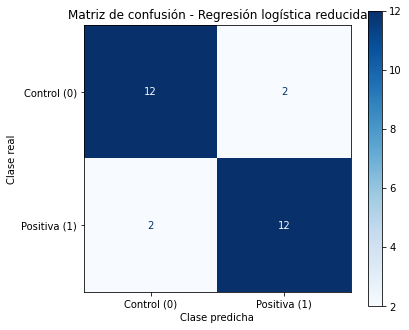

In [72]:
# ============================================================
# 60. MATRIZ DE CONFUSIÓN
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    pred_oof,
    display_labels=["Control (0)", "Positiva (1)"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(
    "Matriz de confusión - Regresión logística reducida"
)

ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")

plt.tight_layout()
plt.show()

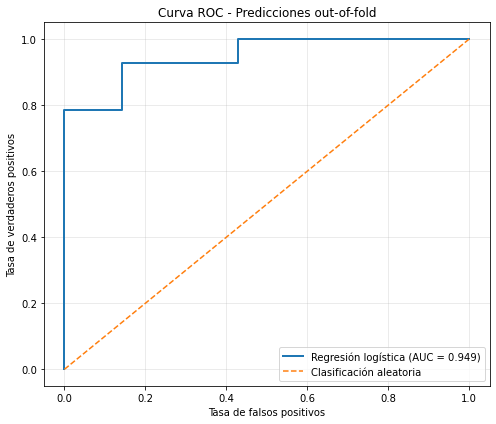

ROC-AUC out-of-fold: 0.949


In [73]:
# ============================================================
# 61. CURVA ROC OUT-OF-FOLD
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(
    y,
    prob_oof
)

# Calcular AUC
auc_oof = roc_auc_score(
    y,
    prob_oof
)

# Crear gráfico
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Regresión logística (AUC = {auc_oof:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title(
    "Curva ROC - Predicciones out-of-fold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(
    "ROC-AUC out-of-fold:",
    round(auc_oof, 3)
)

In [74]:
# ============================================================
# 62. VALIDACIÓN CRUZADA CON SELECCIÓN L1 DENTRO DE CADA FOLD
# ============================================================

from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

pipeline_anidado = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "selector",
        SelectFromModel(
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=0.5,
                max_iter=5000,
                random_state=42
            )
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

resultados_anidados = cross_validate(
    pipeline_anidado,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

resumen_anidado = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Media": [
        resultados_anidados["test_accuracy"].mean(),
        resultados_anidados["test_precision"].mean(),
        resultados_anidados["test_recall"].mean(),
        resultados_anidados["test_f1"].mean(),
        resultados_anidados["test_roc_auc"].mean()
    ],
    "Desviación": [
        resultados_anidados["test_accuracy"].std(),
        resultados_anidados["test_precision"].std(),
        resultados_anidados["test_recall"].std(),
        resultados_anidados["test_f1"].std(),
        resultados_anidados["test_roc_auc"].std()
    ]
})

print("MODELO CON SELECCIÓN L1 DENTRO DE CADA FOLD")
print("=" * 80)

display(resumen_anidado.round(3))

print("\nAccuracy entrenamiento:")
print(
    round(
        resultados_anidados["train_accuracy"].mean(),
        3
    )
)

print("\nAccuracy validación:")
print(
    round(
        resultados_anidados["test_accuracy"].mean(),
        3
    )
)

MODELO CON SELECCIÓN L1 DENTRO DE CADA FOLD


,Métrica,Media,Desviación
0,Accuracy,0.860,0.127
1,Precision,0.933,0.133
2,Recall,0.800,0.163
3,F1-score,0.853,0.129
4,ROC-AUC,0.911,0.130



Accuracy entrenamiento:
0.893

Accuracy validación:
0.86


In [75]:
# ============================================================
# 63. ESTABILIDAD DE LA SELECCIÓN DE VARIABLES ENTRE FOLDS
# ============================================================

import pandas as pd
from sklearn.base import clone

seleccion_por_fold = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # Ajustar únicamente imputación + escalado + selector L1
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train)
    X_train_scaled = scaler.fit_transform(X_train_imp)

    selector = SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            max_iter=5000,
            random_state=42
        )
    )

    selector.fit(X_train_scaled, y_train)

    variables_seleccionadas = X.columns[
        selector.get_support()
    ].tolist()

    seleccion_por_fold.append(
        {
            "Fold": fold,
            "N_variables": len(variables_seleccionadas),
            "Variables": variables_seleccionadas
        }
    )

df_seleccion_folds = pd.DataFrame(seleccion_por_fold)

print("VARIABLES SELECCIONADAS EN CADA FOLD")
print("=" * 100)

for _, fila in df_seleccion_folds.iterrows():

    print(f"\nFOLD {fila['Fold']}")
    print(f"Número de variables: {fila['N_variables']}")

    for variable in fila["Variables"]:
        print("-", variable)


# ============================================================
# FRECUENCIA DE SELECCIÓN
# ============================================================

todas_seleccionadas = [
    variable
    for lista in df_seleccion_folds["Variables"]
    for variable in lista
]

frecuencia_variables = (
    pd.Series(todas_seleccionadas)
    .value_counts()
    .rename_axis("Variable")
    .reset_index(name="N_Folds")
)

frecuencia_variables["Porcentaje"] = (
    frecuencia_variables["N_Folds"] / 5 * 100
)

print("\n" + "=" * 100)
print("ESTABILIDAD DE LAS VARIABLES")
print("=" * 100)

display(frecuencia_variables)

VARIABLES SELECCIONADAS EN CADA FOLD

FOLD 1
Número de variables: 4
- Margen_Neto_t-1
- Debt_Assets_t-1
- Delta_Debt_Equity_t1_t3
- Receivables_Assets_t-1

FOLD 2
Número de variables: 6
- Margen_Neto_t-1
- ROA_t-1
- Debt_Assets_t-1
- Delta_Debt_Equity_t1_t3
- Receivables_Assets_t-1
- Receivables_Revenue_t-1

FOLD 3
Número de variables: 6
- Margen_Neto_t-1
- ROA_t-1
- ROE_t-1
- Debt_Assets_t-1
- Receivables_Assets_t-1
- Delta_Receivables_Revenue_t1_t3

FOLD 4
Número de variables: 6
- Margen_Neto_t-1
- ROA_t-1
- ROE_t-1
- Debt_Assets_t-1
- Delta_Debt_Equity_t1_t3
- Receivables_Assets_t-1

FOLD 5
Número de variables: 5
- Margen_Neto_t-1
- ROA_t-1
- Debt_Assets_t-1
- Delta_Debt_Equity_t1_t3
- Receivables_Assets_t-1

ESTABILIDAD DE LAS VARIABLES


,Variable,N_Folds,Porcentaje
0,Margen_Neto_t-1,5,100.0
1,Debt_Assets_t-1,5,100.0
2,Receivables_Assets_t-1,5,100.0
3,Delta_Debt_Equity_t1_t3,4,80.0
4,ROA_t-1,4,80.0
5,ROE_t-1,2,40.0
6,Receivables_Revenue_t-1,1,20.0
7,Delta_Receivables_Revenue_t1_t3,1,20.0


In [76]:
# ============================================================
# 64. RESUMEN FINAL DE VARIABLES ESTABLES
# ============================================================

variables_estables = frecuencia_variables[
    frecuencia_variables["N_Folds"] >= 4
].copy()

print("VARIABLES CON MAYOR ESTABILIDAD")
print("=" * 80)

display(
    variables_estables.reset_index(drop=True)
)

VARIABLES CON MAYOR ESTABILIDAD


,Variable,N_Folds,Porcentaje
0,Margen_Neto_t-1,5,100.0
1,Debt_Assets_t-1,5,100.0
2,Receivables_Assets_t-1,5,100.0
3,Delta_Debt_Equity_t1_t3,4,80.0
4,ROA_t-1,4,80.0


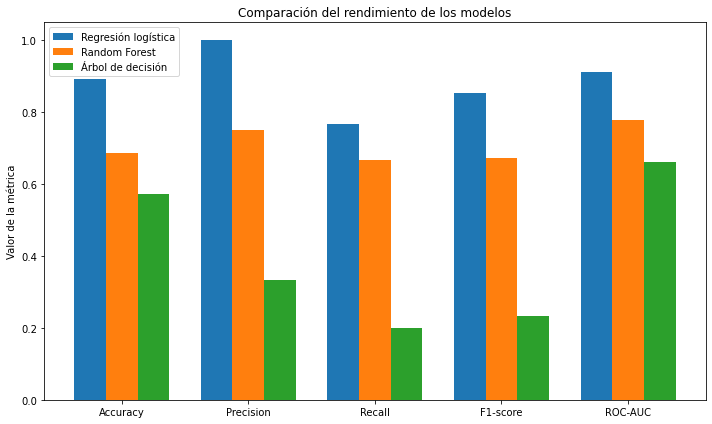

In [77]:
# ============================================================
# GRÁFICO 1. COMPARACIÓN DE MODELOS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

modelos_graf = comparativa_modelos["Modelo"].tolist()

x = np.arange(len(metricas))
ancho = 0.25

plt.figure(figsize=(10, 6))

for i, modelo in enumerate(modelos_graf):

    fila = comparativa_modelos[
        comparativa_modelos["Modelo"] == modelo
    ].iloc[0]

    valores = [
        fila["Accuracy"],
        fila["Precision"],
        fila["Recall"],
        fila["F1-score"],
        fila["ROC-AUC"]
    ]

    plt.bar(
        x + i * ancho,
        valores,
        width=ancho,
        label=modelo
    )

plt.xticks(
    x + ancho,
    metricas,
    rotation=0
)

plt.ylim(0, 1.05)

plt.ylabel("Valor de la métrica")
plt.title("Comparación del rendimiento de los modelos")

plt.legend()

plt.tight_layout()
plt.show()

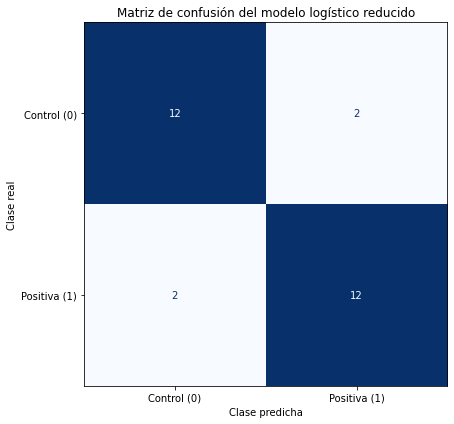

In [79]:
# ============================================================
# GRÁFICO 2. MATRIZ DE CONFUSIÓN
# REGRESIÓN LOGÍSTICA REDUCIDA - PREDICCIONES OUT-OF-FOLD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Matriz de confusión
cm = np.array([
    [12, 2],
    [2, 12]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Positiva (1)"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Matriz de confusión del modelo logístico reducido")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.tight_layout()
plt.show()

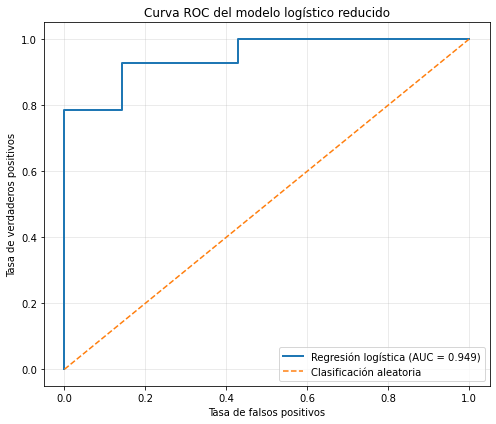

ROC-AUC out-of-fold: 0.949


In [80]:
# ============================================================
# GRÁFICO 3. CURVA ROC OUT-OF-FOLD
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# Curva ROC a partir de las probabilidades out-of-fold
fpr, tpr, thresholds = roc_curve(
    y,
    prob_oof
)

auc_oof = roc_auc_score(
    y,
    prob_oof
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Regresión logística (AUC = {auc_oof:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title(
    "Curva ROC del modelo logístico reducido"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(
    "ROC-AUC out-of-fold:",
    round(auc_oof, 3)
)

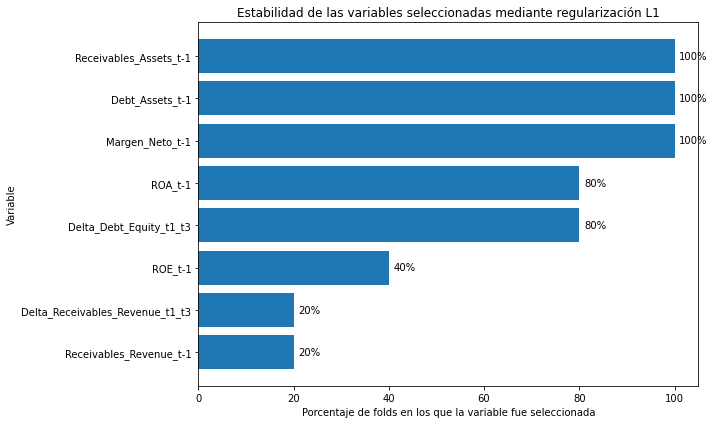

In [81]:
# ============================================================
# GRÁFICO 4. ESTABILIDAD DE LAS VARIABLES SELECCIONADAS
# ============================================================

import matplotlib.pyplot as plt

# Usamos la tabla ya creada:
# frecuencia_variables

variables_plot = frecuencia_variables.copy()

variables_plot = variables_plot.sort_values(
    "Porcentaje",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    variables_plot["Variable"],
    variables_plot["Porcentaje"]
)

plt.xlabel(
    "Porcentaje de folds en los que la variable fue seleccionada"
)

plt.ylabel("Variable")

plt.title(
    "Estabilidad de las variables seleccionadas mediante regularización L1"
)

plt.xlim(0, 105)

# Añadir porcentaje al final de cada barra
for i, valor in enumerate(
    variables_plot["Porcentaje"]
):
    plt.text(
        valor + 1,
        i,
        f"{valor:.0f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

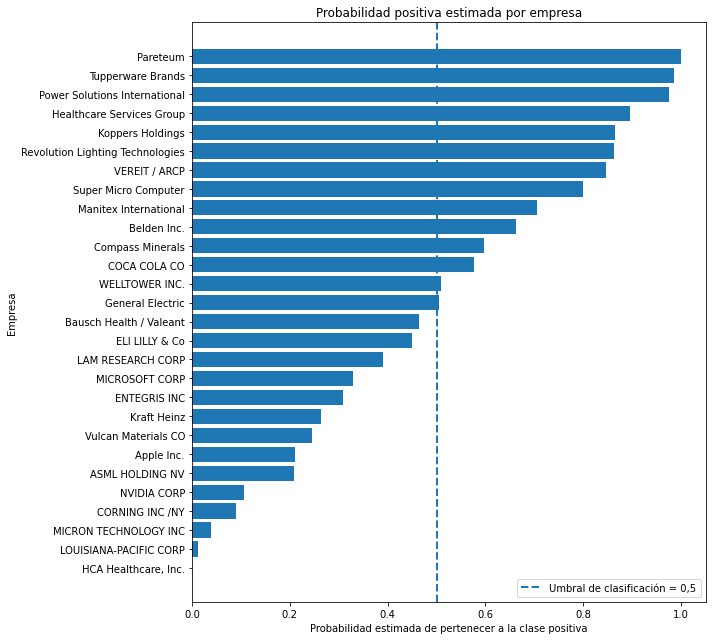

In [82]:
# ============================================================
# GRÁFICO 5. PROBABILIDAD POSITIVA POR EMPRESA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Ordenar por probabilidad
graf_prob = resultados_empresas.copy()

graf_prob = graf_prob.sort_values(
    "Probabilidad_Positiva",
    ascending=True
)

plt.figure(figsize=(10, 9))

plt.barh(
    graf_prob["Empresa"],
    graf_prob["Probabilidad_Positiva"]
)

# Umbral de decisión
plt.axvline(
    x=0.5,
    linestyle="--",
    linewidth=2,
    label="Umbral de clasificación = 0,5"
)

plt.xlabel("Probabilidad estimada de pertenecer a la clase positiva")
plt.ylabel("Empresa")

plt.title(
    "Probabilidad positiva estimada por empresa"
)

plt.xlim(0, 1.05)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()